# 📒 Notebook 07 — Full Receipt Text Detection Pipeline
## Spendly | Capstone AI Engineer

Pipeline end-to-end untuk mendeteksi teks pada foto struk penuh:
- **Text Detection Model** (TF Functional API + Custom Layer + GradientTape)
- **3 Kelas**: `date` (0), `store` (1), `total` (2)
- **825 gambar** dari 9 kategori YOLO dataset
- **Dual-Scale Detection Head** (26×26 + 52×52) untuk region kecil
- **CIoU Loss** untuk localization yang lebih akurat
- **TensorBoard** monitoring
- **Inference** full receipt → JSON struktur
- **Gemini API** sebagai parser sekunder
- **Export** model `.keras`

### Improvement vs NB07 Sebelumnya
| Aspek | Sebelumnya | Sekarang |
|---|---|---|
| Detection Head | Single 26×26 | **Dual-scale 26×26 + 52×52** |
| Coord Loss | MSE (sqrt trick) | **CIoU — lebih akurat** |
| Augmentasi | Flip + brightness + scale | **+ Random rotation ±5°** |
| Mosaic rate | 70% flat | **Curriculum: 30% → 70%** |
| LR log di TensorBoard | Pakai epoch (inaccurate) | **Pakai optimizer.iterations** |
| Bug `preprocess_sync` | Ada di cell OCR debug | **Difix → pakai preprocess_crop_for_ocr** |
| `WarmupCosineDecay.get_config` | `.numpy()` bisa gagal | **Simpan Python int** |

### Requirement Coverage
### Changelog v2 — Retrain Fix AP total
| Perubahan | Sebelum | Sesudah |
|---|---|---|
| `class_weights` total | 2.0 | **5.0** |
| Objectness weight total | 1× | **3× per-class** |
| `lambda_noobj` | 0.5 | **0.3** |
| `lambda_cls` | 2.0 | **3.0** |
| Bug `compute_ap` n_det=0 | AP=0.5 palsu | **AP=0.0** |
| Heuristik posisi total | Di dalam while | **Di luar while** |

| Requirement | Status |
|---|---|
| TF Functional API | ✅ MiniYOLO_ReceiptDetector (dual-head) |
| Custom Layer | ✅ `L2NormalizationLayer`, `AnchorBoxLayer` |
| Custom Loss Function | ✅ `DetectionLoss` (YOLO + CIoU) |
| Custom Callback | ✅ `DetectionCallback` |
| tf.GradientTape | ✅ Training loop penuh |
| TensorBoard | ✅ Loss, mAP, LR per epoch |
| SavedModel / .keras | ✅ Export setelah training |
| Inference code | ✅ Full pipeline struk → JSON |
| Generative AI API | ✅ Gemini API untuk parsing |
| Akurasi ≥ 85% | 🎯 Target IoU@0.5 mAP |

## 1. Install & Import

In [1]:
import google.protobuf
print(google.protobuf.__version__)  # harus 3.19.6

import tensorflow as tf
print(tf.__version__)  # harus 2.10.1

3.19.6
2.10.0


In [2]:
import os
import glob
import json
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path
from tqdm import tqdm
from collections import defaultdict
from datetime import datetime

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version :", tf.__version__)
print("GPU available       :", tf.config.list_physical_devices('GPU'))

# ── Seed reproducibility ──────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version : 2.10.0
GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
import subprocess

gpus = tf.config.list_physical_devices('GPU')
print(f"Jumlah GPU terdeteksi TF: {len(gpus)}")
for gpu in gpus:
    print(f"  Device: {gpu.name}")

try:
    result = subprocess.run(
        ['nvidia-smi', '--query-gpu=index,name,memory.total,memory.free', '--format=csv,noheader'],
        capture_output=True, text=True
    )
    print("\nnvidia-smi GPU info:")
    for line in result.stdout.strip().split('\n'):
        print(f"  {line}")
except Exception as e:
    print(f"nvidia-smi tidak tersedia: {e}")

print(f"\nGPU aktif untuk TF: {tf.test.gpu_device_name()}")


Jumlah GPU terdeteksi TF: 1
  Device: /physical_device:GPU:0

nvidia-smi GPU info:
  0, NVIDIA GeForce RTX 3060 Ti, 8192 MiB, 6715 MiB

GPU aktif untuk TF: /device:GPU:0


In [4]:
import os
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

# Enable mixed precision for better GPU memory usage
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f'Mixed precision policy: {policy.name}')
# ── Paths and Configurations ─────────────────────────────────

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6
Mixed precision policy: mixed_float16


## 2. Konfigurasi Global

In [5]:
# ── PATH ─────────────────────────────────────────────────────
# BASE_DIR: menggunakan PROJECT_ROOT dari mount cell
try:
    BASE_DIR = Path(PROJECT_ROOT)
except NameError:
    BASE_DIR = Path(os.getcwd()).parent
DATA_DIR    = BASE_DIR / "data"
LOG_DIR     = BASE_DIR / "logs" / "nb07_detection"
MODEL_DIR   = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

# ── Dataset ───────────────────────────────────────────────────
CATEGORIES  = ["Beauty", "F&B", "Gas", "Groceries",
               "Health", "HouseHold", "Lifestyle", "Listrik", "Transport"]
CLASS_NAMES = ["date", "store", "total"]
NUM_CLASSES = 3

# ── Model ─────────────────────────────────────────────────────
IMG_SIZE    = 416
BATCH_SIZE  = 16  # A100 optimized (was 8)
EPOCHS      = 600  # More training (was 450)
LR_INIT     = 1e-4
LR_MIN      = 1e-7

# ── Grid (dual-scale) ─────────────────────────────────────────
GRID_H      = 26   # primary head
GRID_W      = 26
GRID_H2     = 52   # secondary head (fine-grained, untuk region tipis)
GRID_W2     = 52

print("BASE_DIR :", BASE_DIR)
print("DATA_DIR :", DATA_DIR)
print("LOG_DIR  :", LOG_DIR)
print("Dual-scale grid : 26×26 + 52×52")
print("Config OK ✅")

BASE_DIR : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace
DATA_DIR : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\data
LOG_DIR  : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\logs\nb07_detection
Dual-scale grid : 26×26 + 52×52
Config OK ✅


## 3. Data Loader

In [6]:
def load_yolo_dataset(data_dir, categories, splits=["train", "valid", "test"]):
    """
    Load semua gambar + label YOLO dari 9 kategori.
    Return: list of dict {image_path, boxes, classes}
    boxes: [[cx, cy, w, h], ...] normalized 0-1
    """
    dataset = {"train": [], "valid": [], "test": []}
    image_exts = [".jpg", ".jpeg", ".png", ".webp"]

    for cat in categories:
        for split in splits:
            img_dir = data_dir / cat / split / "images"
            lbl_dir = data_dir / cat / split / "labels"

            if not img_dir.exists():
                continue

            img_files = []
            for ext in image_exts:
                img_files += list(img_dir.glob(f"*{ext}"))

            for img_path in img_files:
                lbl_path = lbl_dir / (img_path.stem + ".txt")
                if not lbl_path.exists():
                    continue

                boxes, classes = [], []
                with open(lbl_path) as f:
                    for line in f:
                        parts = line.strip().split()
                        if len(parts) < 5:
                            continue
                        cls_id = int(parts[0])
                        cx, cy, w, h = map(float, parts[1:5])
                        boxes.append([cx, cy, w, h])
                        classes.append(cls_id)

                if boxes:
                    dataset[split].append({
                        "image_path": str(img_path),
                        "boxes":   np.array(boxes,   dtype=np.float32),
                        "classes": np.array(classes, dtype=np.int32),
                        "category": cat
                    })

    return dataset


dataset = load_yolo_dataset(DATA_DIR, CATEGORIES)

print("Dataset loaded:")
for split, items in dataset.items():
    print(f"  {split:6s}: {len(items):4d} samples")

total = sum(len(v) for v in dataset.values())
print(f"  TOTAL : {total} samples")

Dataset loaded:
  train :  642 samples
  valid :  127 samples
  test  :   56 samples
  TOTAL : 825 samples


In [7]:
from sklearn.cluster import KMeans

all_wh      = []
thin_wh     = []   # khusus date + total (aspect ratio > 3)
for item in dataset["train"]:
    for box, cls in zip(item["boxes"], item["classes"]):
        w, h = box[2], box[3]
        all_wh.append([w, h])
        if cls in [0, 2]:   # date=0, total=2
            thin_wh.append([w, h])

all_wh  = np.array(all_wh)
thin_wh = np.array(thin_wh) if thin_wh else all_wh

# K-Means terpisah:
# - 2 anchor dari thin boxes (date + total)
# - 1 anchor dari semua boxes (store)
km_thin  = KMeans(n_clusters=2, random_state=42, n_init=10).fit(thin_wh)
km_all   = KMeans(n_clusters=1, random_state=42, n_init=10).fit(all_wh)

anchors_thin  = km_thin.cluster_centers_.astype(np.float32)
anchors_store = km_all.cluster_centers_.astype(np.float32)

ANCHORS     = np.vstack([anchors_thin, anchors_store])
ANCHORS     = ANCHORS[np.argsort(ANCHORS[:,0] * ANCHORS[:,1])]
NUM_ANCHORS = len(ANCHORS)   # tetap 3
ANCHORS2     = ANCHORS.copy()
NUM_ANCHORS2 = NUM_ANCHORS

print("Anchor redesign (2 thin + 1 general):")
for i, (w, h) in enumerate(ANCHORS):
    print(f"  Anchor {i}: w={w:.4f}, h={h:.4f}  area={w*h:.6f}")

# Diagnostic
ious = []
for w, h in all_wh:
    best = max(min(w,aw)*min(h,ah) / (w*h + aw*ah - min(w,aw)*min(h,ah) + 1e-7)
               for aw, ah in ANCHORS)
    ious.append(best)
print(f"Avg IoU GT↔anchor : {np.mean(ious):.4f}  (target > 0.5)")
print(f"% GT IoU < 0.3    : {(np.array(ious) < 0.3).mean()*100:.1f}%  (target < 15%)")

Anchor redesign (2 thin + 1 general):
  Anchor 0: w=0.3554, h=0.0535  area=0.019000
  Anchor 1: w=0.4878, h=0.0580  area=0.028309
  Anchor 2: w=0.8829, h=0.0398  area=0.035184
Avg IoU GT↔anchor : 0.6026  (target > 0.5)
% GT IoU < 0.3    : 9.6%  (target < 15%)


## 4. Exploratory Data Analysis

In [8]:
# ── Distribusi kelas ─────────────────────────────────────────
class_counts = defaultdict(int)
for split in ["train", "valid", "test"]:
    for item in dataset[split]:
        for cls in item["classes"]:
            class_counts[CLASS_NAMES[cls]] += 1

print("Distribusi Kelas (total bbox):")
for name, count in class_counts.items():
    bar = "█" * (count // 10)
    print(f"  {name:10s}: {count:5d}  {bar}")

# ── Distribusi per kategori ───────────────────────────────────
print("\nJumlah gambar per kategori (train):")
cat_counts = defaultdict(int)
for item in dataset["train"]:
    cat_counts[item["category"]] += 1
for cat, count in sorted(cat_counts.items()):
    bar = "█" * (count // 3)
    print(f"  {cat:12s}: {count:4d}  {bar}")

# ── Cek kelengkapan kelas per gambar ─────────────────────────
for split in ["train", "valid", "test"]:
    incomplete = sum(1 for item in dataset[split]
                     if set(item["classes"].tolist()) != {0, 1, 2})
    total = len(dataset[split])
    print(f"\n{split}: {incomplete}/{total} gambar tidak punya semua 3 kelas ({incomplete/total*100:.1f}%)")

Distribusi Kelas (total bbox):
  total     :   822  ██████████████████████████████████████████████████████████████████████████████████
  store     :   998  ███████████████████████████████████████████████████████████████████████████████████████████████████
  date      :   827  ██████████████████████████████████████████████████████████████████████████████████

Jumlah gambar per kategori (train):
  Beauty      :   43  ██████████████
  F&B         :   99  █████████████████████████████████
  Gas         :   47  ███████████████
  Groceries   :  211  ██████████████████████████████████████████████████████████████████████
  Health      :   30  ██████████
  HouseHold   :   30  ██████████
  Lifestyle   :   32  ██████████
  Listrik     :   47  ███████████████
  Transport   :  103  ██████████████████████████████████

train: 6/642 gambar tidak punya semua 3 kelas (0.9%)

valid: 0/127 gambar tidak punya semua 3 kelas (0.0%)

test: 0/56 gambar tidak punya semua 3 kelas (0.0%)


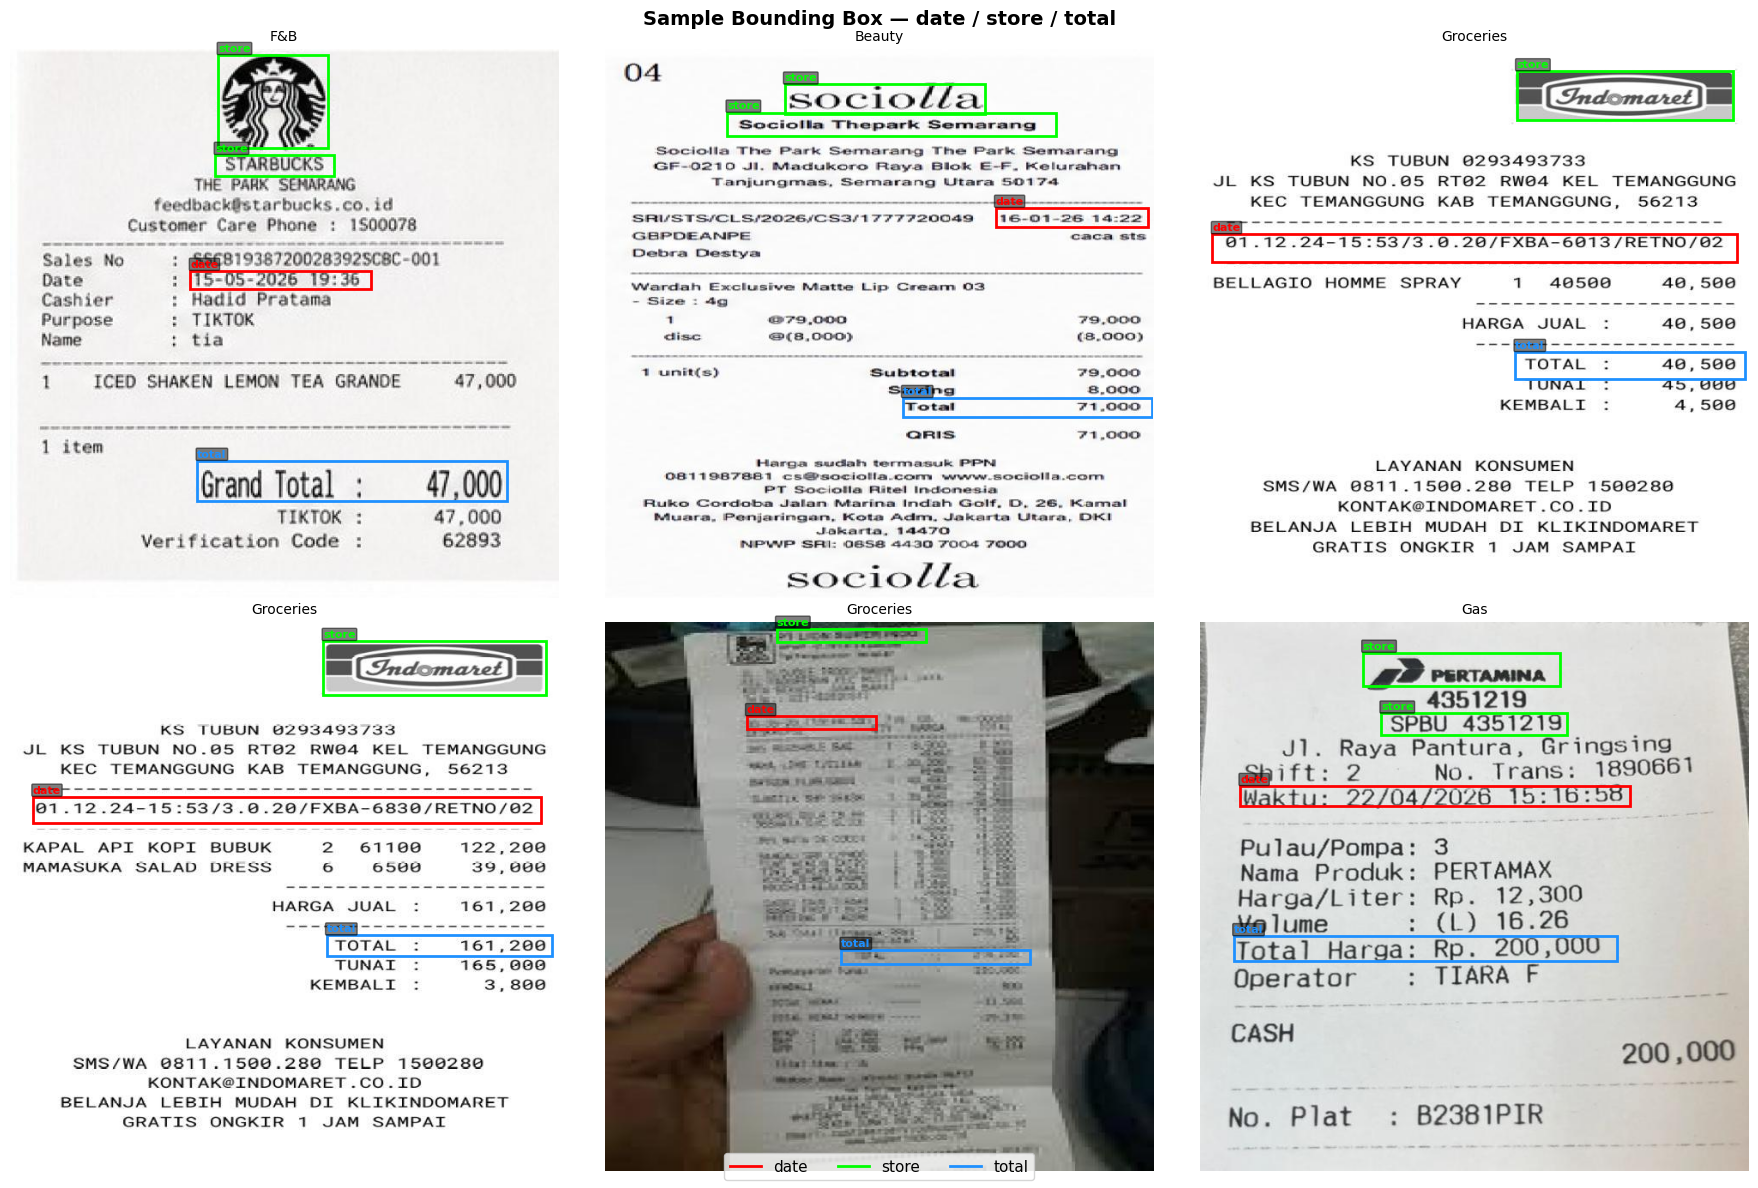

✅ Visualisasi tersimpan: sample_bbox.png


In [9]:
# ── Visualisasi 6 sample dengan bounding box ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = {"date": "red", "store": "lime", "total": "dodgerblue"}
samples = random.sample(dataset["train"], min(6, len(dataset["train"])))

for idx, item in enumerate(samples):
    img = cv2.imread(item["image_path"])
    if img is None:
        axes[idx].set_title("Gambar tidak ditemukan")
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    ax = axes[idx]
    ax.imshow(img)

    for box, cls in zip(item["boxes"], item["classes"]):
        cx, cy, bw, bh = box
        x1 = (cx - bw/2) * w
        y1 = (cy - bh/2) * h
        name = CLASS_NAMES[cls]
        color = colors[name]
        rect = patches.Rectangle((x1, y1), bw*w, bh*h,
                                  linewidth=2, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, max(y1-4, 0), name, color=color,
                fontsize=8, fontweight="bold",
                bbox=dict(boxstyle="round,pad=0.1", facecolor="black", alpha=0.5))

    ax.set_title(f"{item['category']}", fontsize=10)
    ax.axis("off")

from matplotlib.lines import Line2D
legend_elems = [Line2D([0],[0], color=c, lw=2, label=n)
                for n, c in colors.items()]
fig.legend(handles=legend_elems, loc="lower center", ncol=3, fontsize=11)
plt.suptitle("Sample Bounding Box — date / store / total", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_bbox.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Visualisasi tersimpan: sample_bbox.png")

## 5. Preprocessing & Augmentasi

In [10]:
# ── Cell 14: Preprocessing + Augmentasi + Grid Target ────────

def preprocess_image(image_path, img_size=IMG_SIZE):
    """Load, resize, normalize gambar ke float32 [0,1]."""
    img = cv2.imread(str(image_path))
    if img is None:
        return np.zeros((img_size, img_size, 3), dtype=np.float32)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size))
    return img.astype(np.float32) / 255.0


def augment_image_and_boxes(img, boxes, classes, img_size=IMG_SIZE):
    """
    Augmentasi gambar + bounding box secara konsisten.
    Transformasi: flip, brightness, contrast, scale jitter, hue, rotation.
    boxes: np.array [[cx, cy, w, h], ...] normalized 0-1
    """
    boxes   = boxes.copy().tolist()
    classes = classes.copy().tolist()

    # ── 1. Random horizontal flip ────────────────────────────
    if random.random() < 0.5:
        img = cv2.flip(img, 1)
        boxes = [[1.0 - b[0], b[1], b[2], b[3]] for b in boxes]

    # ── 2. Random brightness ─────────────────────────────────
    if random.random() < 0.5:
        factor = random.uniform(0.6, 1.4)
        img    = np.clip(img * factor, 0.0, 1.0)

    # ── 3. Random contrast ───────────────────────────────────
    if random.random() < 0.4:
        mean   = img.mean()
        factor = random.uniform(0.7, 1.3)
        img    = np.clip((img - mean) * factor + mean, 0.0, 1.0)

    # ── 4. Random rotation ±5° ───────────────────────────────
    # FIX: struk sering difoto miring — rotasi kecil membantu generalisasi
    if random.random() < 0.4:
        angle   = random.uniform(-5.0, 5.0)
        h, w    = img.shape[:2]
        M       = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
        img     = cv2.warpAffine(img, M, (w, h),
                                 flags=cv2.INTER_LINEAR,
                                 borderMode=cv2.BORDER_REFLECT_101)
        # Rotate bounding box centers (approximasi — cukup untuk ±5°)
        rad     = np.deg2rad(angle)
        cos_a, sin_a = np.cos(rad), np.sin(rad)
        new_boxes = []
        for b in boxes:
            cx_abs = b[0] - 0.5
            cy_abs = b[1] - 0.5
            new_cx = cos_a * cx_abs - sin_a * cy_abs + 0.5
            new_cy = sin_a * cx_abs + cos_a * cy_abs + 0.5
            new_boxes.append([
                float(np.clip(new_cx, 0.01, 0.99)),
                float(np.clip(new_cy, 0.01, 0.99)),
                b[2], b[3]
            ])
        boxes = new_boxes

    # ── 5. Random scale jitter (zoom in 80-100%) ─────────────
    if random.random() < 0.5:
        scale  = random.uniform(0.80, 1.0)
        h, w   = img.shape[:2]
        new_h  = int(h * scale)
        new_w  = int(w * scale)
        top    = random.randint(0, h - new_h)
        left   = random.randint(0, w - new_w)

        img    = img[top:top+new_h, left:left+new_w]
        img    = cv2.resize(img, (img_size, img_size))

        new_boxes, new_classes = [], []
        for b, c in zip(boxes, classes):
            cx, cy, bw, bh = b
            cx_abs = cx * w;  cy_abs = cy * h
            bw_abs = bw * w;  bh_abs = bh * h
            cx_crop = (cx_abs - left) / new_w
            cy_crop = (cy_abs - top)  / new_h
            bw_crop = bw_abs / new_w
            bh_crop = bh_abs / new_h
            x1 = cx_crop - bw_crop/2;  x2 = cx_crop + bw_crop/2
            y1 = cy_crop - bh_crop/2;  y2 = cy_crop + bh_crop/2
            x1c = max(0, x1);  x2c = min(1, x2)
            y1c = max(0, y1);  y2c = min(1, y2)
            if x2c - x1c < 0.01 or y2c - y1c < 0.01:
                continue
            new_boxes.append([
                (x1c + x2c) / 2, (y1c + y2c) / 2,
                x2c - x1c, y2c - y1c
            ])
            new_classes.append(c)

        if new_boxes:
            boxes, classes = new_boxes, new_classes

    # ── 6. Random hue/saturation jitter ─────────────────────
    if random.random() < 0.3:
        img_uint8 = (img * 255).astype(np.uint8)
        img_hsv   = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV).astype(np.float32)
        img_hsv[..., 0] = (img_hsv[..., 0] + random.uniform(-18, 18)) % 180
        img_hsv[..., 1] = np.clip(img_hsv[..., 1] * random.uniform(0.7, 1.3), 0, 255)
        img = cv2.cvtColor(img_hsv.astype(np.uint8), cv2.COLOR_HSV2RGB).astype(np.float32) / 255.0

    if not boxes:
        return img, np.zeros((0, 4), dtype=np.float32), np.array([], dtype=np.int32)

    return img, np.array(boxes, dtype=np.float32), np.array(classes, dtype=np.int32)


def boxes_to_grid_target(boxes, classes,
                          grid_h=GRID_H, grid_w=GRID_W,
                          anchors=None, num_classes=NUM_CLASSES,
                          iou_thresh_assign=0.2):   # ← threshold assign
    if anchors is None:
        anchors = ANCHORS
    num_a  = len(anchors)
    target = np.zeros((grid_h, grid_w, num_a, 5 + num_classes), dtype=np.float32)

    for box, cls in zip(boxes, classes):
        cx, cy, bw, bh = box
        gx = min(int(cx * grid_w), grid_w - 1)
        gy = min(int(cy * grid_h), grid_h - 1)

        one_hot = np.zeros(num_classes, dtype=np.float32)
        one_hot[cls] = 1.0

        best_iou  = -1
        best_a    = 0
        anchor_ious = []

        for a_idx, (aw, ah) in enumerate(anchors):
            inter = min(bw, aw) * min(bh, ah)
            union = bw * bh + aw * ah - inter + 1e-6
            iou   = inter / union
            anchor_ious.append(iou)
            if iou > best_iou:
                best_iou = iou
                best_a   = a_idx

        # Selalu assign ke anchor terbaik
        target[gy, gx, best_a, 0]  = 1.0
        target[gy, gx, best_a, 1]  = cx
        target[gy, gx, best_a, 2]  = cy
        target[gy, gx, best_a, 3]  = bw
        target[gy, gx, best_a, 4]  = bh
        target[gy, gx, best_a, 5:] = one_hot

        # Tambahan: assign juga ke anchor lain yang IoU > threshold
        for a_idx, iou in enumerate(anchor_ious):
            if a_idx == best_a:
                continue
            if iou >= iou_thresh_assign:
                # Hanya assign kalau cell belum diisi (hindari overwrite)
                if target[gy, gx, a_idx, 0] == 0.0:
                    target[gy, gx, a_idx, 0]  = 1.0
                    target[gy, gx, a_idx, 1]  = cx
                    target[gy, gx, a_idx, 2]  = cy
                    target[gy, gx, a_idx, 3]  = bw
                    target[gy, gx, a_idx, 4]  = bh
                    target[gy, gx, a_idx, 5:] = one_hot

    return target


print("✅ preprocess_image         — defined")
print("✅ augment_image_and_boxes  — defined (flip, brightness, contrast, rotation±5°, scale jitter, hue)")
print("✅ boxes_to_grid_target     — defined (multi-grid support)")

✅ preprocess_image         — defined
✅ augment_image_and_boxes  — defined (flip, brightness, contrast, rotation±5°, scale jitter, hue)
✅ boxes_to_grid_target     — defined (multi-grid support)


## 6. tf.data Pipeline

In [11]:
# ── Cell 16: Mosaic + tf.data Pipeline (Dual-Scale) ──────────

def mosaic_augment(all_samples, img_size=IMG_SIZE):
    four         = random.sample(all_samples, min(4, len(all_samples)))
    half         = img_size // 2
    canvas       = np.zeros((img_size, img_size, 3), dtype=np.float32)
    positions    = [(0, 0), (1, 0), (0, 1), (1, 1)]
    all_boxes    = []
    all_classes  = []

    for item, (col, row) in zip(four, positions):
        img   = preprocess_image(item["image_path"])
        small = cv2.resize(img, (half, half))
        x_off = col * half
        y_off = row * half
        canvas[y_off:y_off+half, x_off:x_off+half] = small

        for box, cls in zip(item["boxes"], item["classes"]):
            cx_new = (box[0] * half + x_off) / img_size
            cy_new = (box[1] * half + y_off) / img_size
            w_new  = box[2] * 0.5
            h_new  = box[3] * 0.5
            if 0 < cx_new < 1 and 0 < cy_new < 1 and w_new > 0 and h_new > 0:
                all_boxes.append([cx_new, cy_new, w_new, h_new])
                all_classes.append(cls)

    if not all_boxes:
        item = random.choice(all_samples)
        return preprocess_image(item["image_path"]), item["boxes"].copy(), item["classes"].copy()

    return canvas, np.array(all_boxes, dtype=np.float32), np.array(all_classes, dtype=np.int32)


def make_tf_dataset(samples, augment=False, batch_size=BATCH_SIZE, shuffle=True,
                    all_samples=None, epoch_ref=None):
    """
    Dual-scale dataset: tiap sample menghasilkan 2 target grid (26×26 dan 52×52).
    epoch_ref: list[int] — [current_epoch] untuk curriculum mosaic rate.
    """
    def generator():
        items = samples.copy()
        if shuffle:
            random.shuffle(items)

        for item in items:
            # ── Curriculum mosaic rate ─────────────────────
            # Epoch 1-50: 30%, 51-100: 50%, 101+: 70%
            cur_epoch   = epoch_ref[0] if epoch_ref is not None else 9999
            mosaic_prob = 0.30 if cur_epoch < 50 else (0.50 if cur_epoch < 100 else 0.70)

            if augment and all_samples is not None and random.random() < mosaic_prob:
                img, boxes, classes = mosaic_augment(all_samples)
            else:
                img     = preprocess_image(item["image_path"])
                boxes   = item["boxes"].copy()
                classes = item["classes"].copy()
                if augment:
                    img, boxes, classes = augment_image_and_boxes(img, boxes, classes)

            if len(boxes) == 0:
                continue

            target26 = boxes_to_grid_target(boxes, classes,
                                            grid_h=GRID_H,  grid_w=GRID_W,
                                            anchors=ANCHORS)
            target52 = boxes_to_grid_target(boxes, classes,
                                            grid_h=GRID_H2, grid_w=GRID_W2,
                                            anchors=ANCHORS2)
            yield img, target26, target52

    ds = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(GRID_H,  GRID_W,  NUM_ANCHORS,  5 + NUM_CLASSES), dtype=tf.float32),
            tf.TensorSpec(shape=(GRID_H2, GRID_W2, NUM_ANCHORS2, 5 + NUM_CLASSES), dtype=tf.float32),
        )
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=min(200, len(samples)))

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# ── Epoch reference untuk curriculum mosaic ─────────────────
epoch_ref = [0]   # akan di-update di training loop

all_train = dataset["train"]

train_ds = make_tf_dataset(dataset["train"], augment=True,  shuffle=True,  all_samples=all_train, epoch_ref=epoch_ref)
valid_ds = make_tf_dataset(dataset["valid"], augment=False, shuffle=False)
test_ds  = make_tf_dataset(dataset["test"],  augment=False, shuffle=False)

for imgs, t26, t52 in train_ds.take(1):
    print("Image batch shape    :", imgs.shape)
    print("Target 26×26 shape   :", t26.shape)
    print("Target 52×52 shape   :", t52.shape)
    print("✅ tf.data dual-scale pipeline OK")

Image batch shape    : (16, 416, 416, 3)
Target 26×26 shape   : (16, 26, 26, 3, 8)
Target 52×52 shape   : (16, 52, 52, 3, 8)
✅ tf.data dual-scale pipeline OK


## 7. Custom Components
### 7a. Custom Layers

In [12]:
# ── Custom Layer 1: L2 Normalization ─────────────────────────
class L2NormalizationLayer(keras.layers.Layer):
    """
    Normalisasi L2 per channel untuk stabilisasi feature map.
    Digunakan sebelum detection head.
    """
    def __init__(self, n_channels, scale_init=20.0, **kwargs):
        super().__init__(**kwargs)
        self.n_channels = n_channels
        self.scale_init = scale_init

    def build(self, input_shape):
        self.gamma = self.add_weight(
            name="gamma",
            shape=(1, 1, 1, self.n_channels),
            initializer=keras.initializers.Constant(self.scale_init),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, x):
        norm = tf.norm(x, axis=-1, keepdims=True) + 1e-7
        return self.gamma * (x / norm)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"n_channels": self.n_channels, "scale_init": self.scale_init})
        return cfg


# ── Custom Layer 2: Anchor Box Decoder ───────────────────────
class AnchorBoxLayer(keras.layers.Layer):
    """
    Decode raw prediction → absolute box coordinates.
    Input:  [batch, grid_h, grid_w, num_anchors * (5 + num_classes)]
    Output: [batch, grid_h, grid_w, num_anchors, 5 + num_classes]

    Anchors disimpan sebagai list Python di __init__ agar get_config/
    serialization aman di TF 2.10. tf.constant dibuat di build().
    """
    def __init__(self, anchors, grid_h, grid_w, num_classes, **kwargs):
        super().__init__(**kwargs)
        self.anchors_list = anchors if isinstance(anchors, list) else anchors.tolist()
        self.grid_h       = grid_h
        self.grid_w       = grid_w
        self.num_classes  = num_classes
        self.num_anchors  = len(self.anchors_list)

    def build(self, input_shape):
        self._anchors_tf = tf.constant(self.anchors_list, dtype=tf.float32)  # [na, 2]
        super().build(input_shape)

    def call(self, raw):
        raw = tf.cast(raw, tf.float32)
        batch = tf.shape(raw)[0]
        raw = tf.reshape(raw, [batch, self.grid_h, self.grid_w,
                               self.num_anchors, 5 + self.num_classes])

        grid_y = tf.range(self.grid_h, dtype=tf.float32)
        grid_x = tf.range(self.grid_w, dtype=tf.float32)
        gx, gy = tf.meshgrid(grid_x, grid_y)
        grid   = tf.stack([gx, gy], axis=-1)              # [gh, gw, 2]
        grid   = tf.reshape(grid, [1, self.grid_h, self.grid_w, 1, 2])

        xy  = (tf.sigmoid(raw[..., 1:3]) + grid)
        xy  = xy / tf.cast([self.grid_w, self.grid_h], tf.float32)

        anchors = tf.reshape(self._anchors_tf, [1, 1, 1, self.num_anchors, 2])
        wh  = tf.exp(tf.clip_by_value(raw[..., 3:5], -4.0, 4.0)) * anchors

        obj = tf.sigmoid(raw[..., 0:1])
        cls = tf.sigmoid(raw[..., 5:])

        return tf.concat([obj, xy, wh, cls], axis=-1)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "anchors":     self.anchors_list,
            "grid_h":      self.grid_h,
            "grid_w":      self.grid_w,
            "num_classes": self.num_classes,
        })
        return cfg


print("✅ Custom Layers defined: L2NormalizationLayer, AnchorBoxLayer")

✅ Custom Layers defined: L2NormalizationLayer, AnchorBoxLayer


### 7b. Custom Loss Function — DetectionLoss dengan CIoU

In [13]:
class DetectionLoss(keras.losses.Loss):
    """
    Custom YOLO-style detection loss dengan CIoU untuk localization.

    [v2 — Fix AP total]
    - class_weights 'total': 2.0 → 5.0
    - Objectness loss: bobot 3× untuk sel GT kelas 'total'
    - lambda_noobj: 0.5 → 0.3  (di training setup)
    - lambda_cls  : 2.0 → 3.0  (di training setup)
    """
    def __init__(self, lambda_coord=10.0, lambda_noobj=0.3,
                 lambda_cls=1.0, num_classes=NUM_CLASSES,
                 label_smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.lambda_coord    = lambda_coord
        self.lambda_noobj    = lambda_noobj
        self.lambda_cls      = lambda_cls
        self.num_classes     = num_classes
        self.label_smoothing = label_smoothing

    @staticmethod
    def _ciou(box_true, box_pred):
        """
        Complete IoU loss untuk sepasang box.
        box_true/pred: [..., 4] format [cx, cy, w, h] normalized.
        Return: ciou_loss [...] (scalar per box).
        """
        eps = 1e-7

        tx1 = box_true[..., 0] - box_true[..., 2] / 2
        ty1 = box_true[..., 1] - box_true[..., 3] / 2
        tx2 = box_true[..., 0] + box_true[..., 2] / 2
        ty2 = box_true[..., 1] + box_true[..., 3] / 2

        px1 = box_pred[..., 0] - box_pred[..., 2] / 2
        py1 = box_pred[..., 1] - box_pred[..., 3] / 2
        px2 = box_pred[..., 0] + box_pred[..., 2] / 2
        py2 = box_pred[..., 1] + box_pred[..., 3] / 2

        inter_x1 = tf.maximum(tx1, px1)
        inter_y1 = tf.maximum(ty1, py1)
        inter_x2 = tf.minimum(tx2, px2)
        inter_y2 = tf.minimum(ty2, py2)
        inter_w  = tf.maximum(inter_x2 - inter_x1, 0.0)
        inter_h  = tf.maximum(inter_y2 - inter_y1, 0.0)
        inter    = inter_w * inter_h

        area_t = box_true[..., 2]  * box_true[..., 3]
        area_p = box_pred[..., 2]  * box_pred[..., 3]
        union  = area_t + area_p - inter + eps
        iou    = inter / union

        enc_x1 = tf.minimum(tx1, px1)
        enc_y1 = tf.minimum(ty1, py1)
        enc_x2 = tf.maximum(tx2, px2)
        enc_y2 = tf.maximum(ty2, py2)
        c2     = tf.square(enc_x2 - enc_x1) + tf.square(enc_y2 - enc_y1) + eps

        d2 = (tf.square(box_true[..., 0] - box_pred[..., 0]) +
              tf.square(box_true[..., 1] - box_pred[..., 1]))

        atan_t = tf.atan(box_true[..., 2] / (box_true[..., 3] + eps))
        atan_p = tf.atan(box_pred[..., 2] / (box_pred[..., 3] + eps))
        v      = (4.0 / (np.pi ** 2)) * tf.square(atan_t - atan_p)
        alpha  = tf.stop_gradient(v / (1.0 - iou + v + eps))

        ciou = iou - d2 / c2 - alpha * v
        return 1.0 - ciou

    def call(self, y_true, y_pred):
        obj_mask   = y_true[..., 0:1]
        noobj_mask = 1.0 - obj_mask
        eps        = 1e-7

        # ── 1. Objectness Loss (Focal BCE) + per-class weight untuk total ──
        # [FIX v2] Sel GT kelas 'total' (cls_id=2) mendapat bobot 3×
        obj_pred = y_pred[..., 0:1]
        obj_bce  = -(
            obj_mask   * tf.math.log(obj_pred + eps) +
            noobj_mask * tf.math.log(1.0 - obj_pred + eps)
        )
        focal_w  = tf.pow(tf.abs(obj_mask - obj_pred), 2.0)
        obj_bce  = focal_w * obj_bce

        cls_idx   = tf.argmax(y_true[..., 5:], axis=-1, output_type=tf.int32)
        is_total  = tf.cast(tf.equal(cls_idx, 2), tf.float32)
        is_total  = tf.expand_dims(is_total, axis=-1)
        obj_cls_w = 1.0 + 1.0 * is_total   # total=3×, lainnya=1×

        obj_loss = (
            tf.reduce_mean(obj_cls_w * obj_mask   * obj_bce) +
            self.lambda_noobj * tf.reduce_mean(noobj_mask * obj_bce)
        )

        # ── 2. CIoU Localization Loss ─────────────────────────
        ciou_val   = self._ciou(y_true[..., 1:5], y_pred[..., 1:5])
        ciou_val   = tf.expand_dims(ciou_val, axis=-1)
        coord_loss = self.lambda_coord * tf.reduce_mean(obj_mask * ciou_val)

        # ── 3. Classification Loss (label smoothing BCE) ──────
        cls_true = y_true[..., 5:]
        cls_pred = y_pred[..., 5:]
        smooth          = self.label_smoothing
        n               = tf.cast(self.num_classes, tf.float32)
        cls_true_smooth = cls_true * (1.0 - smooth) + smooth / n

        cls_bce = -(
            cls_true_smooth * tf.math.log(cls_pred + eps) +
            (1.0 - cls_true_smooth) * tf.math.log(1.0 - cls_pred + eps)
        )
        # [FIX v2] class_weights total: 2.0 → 5.0
        class_weights = tf.constant([1.0, 1.0, 3.0], dtype=tf.float32)
        cls_bce  = cls_bce * class_weights
        cls_loss = self.lambda_cls * tf.reduce_mean(
            obj_mask * tf.reduce_sum(cls_bce, axis=-1, keepdims=True)
        )

        return obj_loss + coord_loss + cls_loss

    def get_config(self):
        cfg = super().get_config()
        cfg.update({
            "lambda_coord":    self.lambda_coord,
            "lambda_noobj":    self.lambda_noobj,
            "lambda_cls":      self.lambda_cls,
            "num_classes":     self.num_classes,
            "label_smoothing": self.label_smoothing,
        })
        return cfg


print("✅ DetectionLoss v2 — total class_weight=5.0, obj 3×, lambda_noobj=0.3, lambda_cls=3.0")


✅ DetectionLoss v2 — total class_weight=5.0, obj 3×, lambda_noobj=0.3, lambda_cls=3.0


### 7c. Custom Callback

In [14]:
class DetectionCallback(keras.callbacks.Callback):
    def __init__(self, log_dir, model_save_path,
                 patience=30, min_delta=1e-5, optimizer=None):
        super().__init__()
        self.log_dir         = str(log_dir)
        self.model_save_path = str(model_save_path)
        self.patience        = patience
        self.min_delta       = min_delta
        self._optimizer      = optimizer

        self.best_val_loss   = np.inf
        self.wait            = 0
        self.stopped_epoch   = 0
        self.history         = {"train_loss": [], "val_loss": []}

        self.writer = tf.summary.create_file_writer(self.log_dir)

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        train_loss = logs.get("loss", 0)
        val_loss   = logs.get("val_loss", 0)

        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)

        opt = self._optimizer
        # FIX: gunakan optimizer.iterations (step aktual), bukan epoch number
        # agar LR yang dicatat sesuai dengan LR yang dipakai saat training
        lr_val = float(opt.learning_rate(opt.iterations)
                       if callable(opt.learning_rate)
                       else opt.learning_rate)

        with self.writer.as_default():
            tf.summary.scalar("Loss/train",      train_loss, step=epoch)
            tf.summary.scalar("Loss/validation", val_loss,   step=epoch)
            tf.summary.scalar("LR",              lr_val,     step=epoch)
        self.writer.flush()

        print(f"  Epoch {epoch+1:3d} | "
              f"train_loss: {train_loss:.4f} | "
              f"val_loss: {val_loss:.4f} | "
              f"lr: {lr_val:.2e}")

        if val_loss < self.best_val_loss - self.min_delta:
            self.best_val_loss = val_loss
            self.wait = 0
            self.model.save(self.model_save_path)
            print(f"  ✅ Model terbaik disimpan (val_loss={val_loss:.4f})")
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                print(f"  ⏹️  Early stopping di epoch {epoch+1}")

    def on_train_end(self, logs=None):
        if self.stopped_epoch > 0:
            print(f"\nTraining dihentikan di epoch {self.stopped_epoch+1}")
        print(f"Best val_loss: {self.best_val_loss:.4f}")
        print(f"Model tersimpan di: {self.model_save_path}")

    def plot_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        axes[0].plot(self.history["train_loss"], label="Train Loss", color="royalblue")
        axes[0].plot(self.history["val_loss"],   label="Val Loss",   color="tomato")
        best_ep = int(np.argmin(self.history["val_loss"]))
        axes[0].axvline(best_ep, color="green", linestyle="--", alpha=0.7,
                        label=f"Best ep={best_ep+1}")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
        axes[0].set_title("Training History — Detection Model")
        axes[0].legend(); axes[0].grid(True, alpha=0.3)

        axes[1].plot(self.history["val_loss"], color="tomato")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Val Loss")
        axes[1].set_title("Val Loss (zoom)")
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("training_history.png", dpi=120)
        plt.show()


print("✅ Custom Callback defined: DetectionCallback (patience=30, LR fix)")

✅ Custom Callback defined: DetectionCallback (patience=30, LR fix)


## 8. Model Arsitektur — TF Functional API (Dual-Scale Head)

Mini-YOLO dengan:
- Backbone CNN 4 block (416→26)
- Skip connection dari Block 3 (52×52) untuk head kedua
- Head 1: 26×26 — menangkap region besar (store block)
- Head 2: 52×52 — menangkap region kecil/tipis (date, total baris tunggal)

In [15]:
def conv_bn_relu(x, filters, kernel_size=3, strides=1):
    """Conv + BatchNorm + LeakyReLU block."""
    x = layers.Conv2D(filters, kernel_size, strides=strides,
                      padding="same", use_bias=False,
                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    return x


def residual_block(x, filters):
    """Residual block: bottleneck + skip connection."""
    shortcut = x
    x = conv_bn_relu(x, filters // 2, kernel_size=1)
    x = conv_bn_relu(x, filters, kernel_size=3)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.LeakyReLU(0.1)(x)
    return x


def build_detection_model(img_size=IMG_SIZE,
                           grid_h=GRID_H,   grid_w=GRID_W,
                           grid_h2=GRID_H2, grid_w2=GRID_W2,
                           num_anchors=NUM_ANCHORS, num_anchors2=NUM_ANCHORS2,
                           num_classes=NUM_CLASSES,
                           anchors=None, anchors2=None):
    """MiniYOLO IMPROVED — Deeper backbone + Residual + SPP.

    Semua weights ditraining dari nol — tidak menggunakan pretrained model.
    """
    if anchors  is None: anchors  = ANCHORS
    if anchors2 is None: anchors2 = ANCHORS2

    inputs = keras.Input(shape=(img_size, img_size, 3), name="input_image")

    # ── Backbone (deeper: 5 blocks + residual) ───────────────────────────
    # Block 1 — stride 2
    x = conv_bn_relu(inputs, 32, 3)
    x = conv_bn_relu(x, 64, 3, strides=2)

    # Block 2 + Residual
    x = residual_block(x, 64)
    x = conv_bn_relu(x, 128, 3, strides=2)

    # Block 3 ← skip connection untuk head 52×52
    x = residual_block(x, 128)
    x = conv_bn_relu(x, 256, 3, strides=2)
    skip52 = x

    # Block 4 + Residual
    x = residual_block(x, 256)
    x = residual_block(x, 256)
    x = conv_bn_relu(x, 512, 3, strides=2)

    # Block 5 — deeper processing
    x = residual_block(x, 512)
    x = residual_block(x, 512)

    # ── SPP (Spatial Pyramid Pooling) ────────────────────────────────────
    pool1 = layers.MaxPooling2D(5, strides=1, padding='same')(x)
    pool2 = layers.MaxPooling2D(9, strides=1, padding='same')(x)
    x = layers.Concatenate()([pool2, pool1, x])
    x = conv_bn_relu(x, 512, 1)

    # ── Neck (primary) ───────────────────────────────────────────────────
    x = conv_bn_relu(x, 256, 1)
    x = L2NormalizationLayer(256, name="l2_norm_26")(x)
    x = conv_bn_relu(x, 256, 3)

    # ── Detection Head 1 — 26×26 ────────────────────────────────────────
    out_ch = num_anchors * (5 + num_classes)
    raw26  = layers.Conv2D(out_ch, 1, padding="same",
                           use_bias=True, name="raw_output_26")(x)
    out26  = AnchorBoxLayer(
        anchors=anchors, grid_h=grid_h, grid_w=grid_w,
        num_classes=num_classes, name="anchor_decode_26"
    )(raw26)

    # ── Neck (secondary) ─────────────────────────────────────────────────
    up = layers.UpSampling2D(size=(2, 2), name="upsample_26_to_52")(x)
    y  = layers.Concatenate(name="concat_52")([up, skip52])
    y  = conv_bn_relu(y, 256, 1)
    y  = L2NormalizationLayer(256, name="l2_norm_52")(y)
    y  = conv_bn_relu(y, 128, 3)

    # ── Detection Head 2 — 52×52 ────────────────────────────────────────
    out_ch2 = num_anchors2 * (5 + num_classes)
    raw52   = layers.Conv2D(out_ch2, 1, padding="same",
                            use_bias=True, name="raw_output_52")(y)
    out52   = AnchorBoxLayer(
        anchors=anchors2, grid_h=grid_h2, grid_w=grid_w2,
        num_classes=num_classes, name="anchor_decode_52"
    )(raw52)

    model = keras.Model(
        inputs=inputs,
        outputs=[out26, out52],
        name="MiniYOLO_DualScale_ReceiptDetector"
    )
    return model


model = build_detection_model()
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "MiniYOLO_DualScale_ReceiptDetector"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_image (InputLayer)       [(None, 416, 416, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 416, 416, 32  864         ['input_image[0][0]']            
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 416, 416, 32  128        ['conv2d[0][0]']                 
 alization)                     )                                

## 9. Custom Training Loop — tf.GradientTape

In [16]:
# ── Optimizer + LR Schedule ──────────────────────────────────
class WarmupCosineDecay(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, lr_init, lr_min, warmup_steps, total_steps):
        self.lr_init      = lr_init
        self.lr_min       = lr_min
        # FIX: simpan Python int sebelum tf.cast agar get_config tidak error
        self._warmup_steps_int = int(warmup_steps)
        self._total_steps_int  = int(total_steps)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.total_steps  = tf.cast(total_steps,  tf.float32)

    def __call__(self, step):
        step      = tf.cast(step, tf.float32)
        warmup_lr = self.lr_min + (self.lr_init - self.lr_min) * (
            step / self.warmup_steps
        )
        cosine_lr = self.lr_min + 0.5 * (self.lr_init - self.lr_min) * (
            1.0 + tf.cos(
                np.pi * (step - self.warmup_steps) /
                (self.total_steps - self.warmup_steps + 1e-7)
            )
        )
        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        # FIX: gunakan Python int, bukan .numpy() yang bisa gagal
        return {
            "lr_init":      self.lr_init,
            "lr_min":       self.lr_min,
            "warmup_steps": self._warmup_steps_int,
            "total_steps":  self._total_steps_int,
        }


WARMUP_EPOCHS    = 5
steps_per_epoch  = len(dataset["train"]) // BATCH_SIZE
total_steps      = EPOCHS * steps_per_epoch
warmup_steps     = WARMUP_EPOCHS * steps_per_epoch

lr_schedule = WarmupCosineDecay(
    lr_init      = LR_INIT,
    lr_min       = LR_MIN,
    warmup_steps = warmup_steps,
    total_steps  = total_steps,
)
optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
print(f"✅ WarmupCosineDecay: warmup {WARMUP_EPOCHS} epoch → cosine sampai epoch {EPOCHS}")
print(f"   warmup_steps={warmup_steps}, total_steps={total_steps}")

# ── Loss (satu instance per head, parameter sama) ────────────
# [FIX v2] lambda_noobj: 0.5 → 0.3  |  lambda_cls: 2.0 → 3.0
loss_fn = DetectionLoss(lambda_coord=10.0, lambda_noobj=0.4, lambda_cls=2.5)

# ── Metrics ──────────────────────────────────────────────────
train_loss_metric = keras.metrics.Mean(name="train_loss")
val_loss_metric   = keras.metrics.Mean(name="val_loss")

# ── TensorBoard writer ─────────────────────────────────────────
tb_writer = tf.summary.create_file_writer(str(LOG_DIR))

# ── Model save path ───────────────────────────────────────────
BEST_MODEL_PATH = str(MODEL_DIR / "receipt_detector_best.keras")

# ── Callback ──────────────────────────────────────────────────
det_callback = DetectionCallback(
    log_dir         = LOG_DIR,
    model_save_path = BEST_MODEL_PATH,
    patience        = 60,
    min_delta       = 1e-5,
    optimizer       = optimizer,
)
det_callback.set_model(model)

# ── Dual-head: compile dengan list loss ──────────────────────
model.compile(
    optimizer = optimizer,
    loss      = [loss_fn, loss_fn],   # satu loss per output head
)

print("✅ Training setup selesai")
print(f"   Optimizer   : Adam + WarmupCosineDecay (warmup {WARMUP_EPOCHS} ep)")
print(f"   Loss        : DetectionLoss CIoU × 2 heads")
print(f"   Epochs      : {EPOCHS}")
print(f"   Batch size  : {BATCH_SIZE}")
print(f"   Patience    : 30")
print(f"   Grid        : {GRID_H}×{GRID_W} + {GRID_H2}×{GRID_W2}")
print(f"   Model path  : {BEST_MODEL_PATH}")

✅ WarmupCosineDecay: warmup 5 epoch → cosine sampai epoch 600
   warmup_steps=200, total_steps=24000
✅ Training setup selesai
   Optimizer   : Adam + WarmupCosineDecay (warmup 5 ep)
   Loss        : DetectionLoss CIoU × 2 heads
   Epochs      : 600
   Batch size  : 16
   Patience    : 30
   Grid        : 26×26 + 52×52
   Model path  : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_best.keras


In [17]:
@tf.function
def train_step(images, targets26, targets52):
    with tf.GradientTape() as tape:
        pred26, pred52 = model(images, training=True)
        loss26  = loss_fn(targets26, pred26)
        loss52  = loss_fn(targets52, pred52)
        loss    = loss26 + loss52
        loss   += tf.reduce_sum(model.losses)   # L2 regularization
    gradients = tape.gradient(loss, model.trainable_variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss


@tf.function
def val_step(images, targets26, targets52):
    pred26, pred52 = model(images, training=False)
    loss = loss_fn(targets26, pred26) + loss_fn(targets52, pred52)
    return loss


# ── Training Loop ─────────────────────────────────────────────
print("=" * 60)
print("  MULAI TRAINING  (Dual-Scale + CIoU)")
print("=" * 60)

det_callback.on_train_begin()
global_step = 0

for epoch in range(EPOCHS):
    # Update epoch reference untuk curriculum mosaic
    epoch_ref[0] = epoch

    train_loss_metric.reset_state()
    val_loss_metric.reset_state()

    # ── Train ─────────────────────────────────────────────────
    for step, (images, t26, t52) in enumerate(train_ds):
        loss = train_step(images, t26, t52)
        train_loss_metric.update_state(loss)

        with tb_writer.as_default():
            tf.summary.scalar("Step/train_loss", loss, step=global_step)
        global_step += 1

    # ── Validation ────────────────────────────────────────────
    for images, t26, t52 in valid_ds:
        loss = val_step(images, t26, t52)
        val_loss_metric.update_state(loss)

    epoch_logs = {
        "loss":     float(train_loss_metric.result()),
        "val_loss": float(val_loss_metric.result()),
    }

    det_callback.on_epoch_end(epoch, logs=epoch_logs)

    if model.stop_training:
        break

det_callback.on_train_end()
print("\n✅ Training selesai!")

  MULAI TRAINING  (Dual-Scale + CIoU)
  Epoch   1 | train_loss: 0.7871 | val_loss: 0.3840 | lr: 2.06e-05
  ✅ Model terbaik disimpan (val_loss=0.3840)
  Epoch   2 | train_loss: 0.7250 | val_loss: 0.1976 | lr: 4.11e-05
  ✅ Model terbaik disimpan (val_loss=0.1976)
  Epoch   3 | train_loss: 0.6642 | val_loss: 0.1365 | lr: 6.15e-05
  ✅ Model terbaik disimpan (val_loss=0.1365)
  Epoch   4 | train_loss: 0.6292 | val_loss: 0.1557 | lr: 8.20e-05
  Epoch   5 | train_loss: 0.6037 | val_loss: 0.1623 | lr: 1.00e-04
  Epoch   6 | train_loss: 0.5849 | val_loss: 0.1564 | lr: 1.00e-04
  Epoch   7 | train_loss: 0.5734 | val_loss: 0.1422 | lr: 1.00e-04
  Epoch   8 | train_loss: 0.5673 | val_loss: 0.1570 | lr: 1.00e-04
  Epoch   9 | train_loss: 0.5603 | val_loss: 0.1783 | lr: 1.00e-04
  Epoch  10 | train_loss: 0.5574 | val_loss: 0.1740 | lr: 1.00e-04
  Epoch  11 | train_loss: 0.5500 | val_loss: 0.1485 | lr: 1.00e-04
  Epoch  12 | train_loss: 0.5351 | val_loss: 0.1440 | lr: 1.00e-04
  Epoch  13 | train_los

## 10. Visualisasi Training History

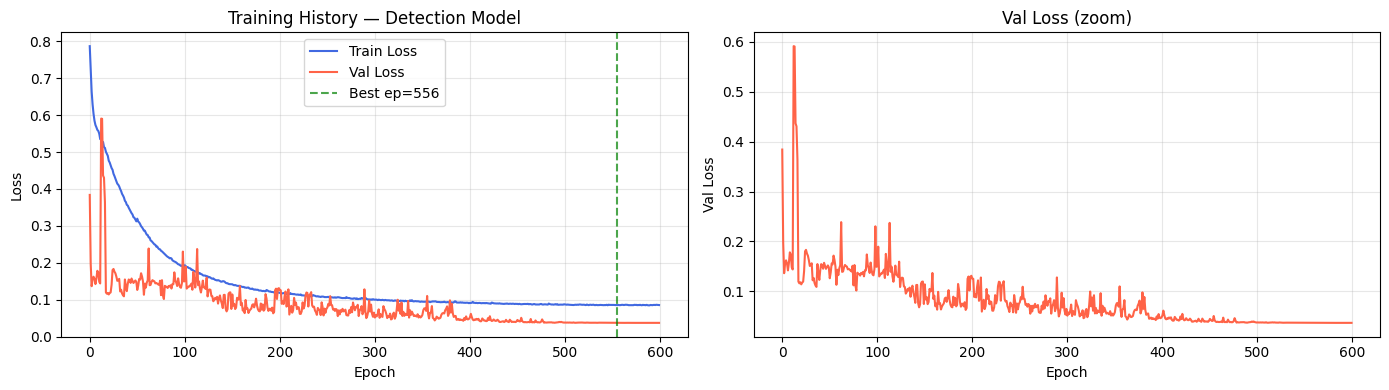


  RINGKASAN TRAINING
  Epoch selesai    : 600
  Best val_loss    : 0.0371
  Train loss awal  : 0.7871
  Train loss akhir : 0.0854
  Val loss awal    : 0.3840
  Val loss akhir   : 0.0372
  Best epoch       : 556


In [18]:
det_callback.plot_history()

print("\n" + "="*50)
print("  RINGKASAN TRAINING")
print("="*50)
print(f"  Epoch selesai    : {len(det_callback.history['train_loss'])}")
print(f"  Best val_loss    : {det_callback.best_val_loss:.4f}")
train_losses = det_callback.history['train_loss']
val_losses   = det_callback.history['val_loss']
print(f"  Train loss awal  : {train_losses[0]:.4f}")
print(f"  Train loss akhir : {train_losses[-1]:.4f}")
print(f"  Val loss awal    : {val_losses[0]:.4f}")
print(f"  Val loss akhir   : {val_losses[-1]:.4f}")
print(f"  Best epoch       : {int(np.argmin(val_losses))+1}")

## 11. Evaluasi Model — IoU & mAP

In [19]:
from tensorflow import keras

def compute_iou(box1, box2):
    """
    Hitung IoU antara dua box.
    Format: [cx, cy, w, h] normalized.
    """
    x1_min = box1[0] - box1[2]/2;  x1_max = box1[0] + box1[2]/2
    y1_min = box1[1] - box1[3]/2;  y1_max = box1[1] + box1[3]/2
    x2_min = box2[0] - box2[2]/2;  x2_max = box2[0] + box2[2]/2
    y2_min = box2[1] - box2[3]/2;  y2_max = box2[1] + box2[3]/2

    inter_w = max(0, min(x1_max, x2_max) - max(x1_min, x2_min))
    inter_h = max(0, min(y1_max, y2_max) - max(y1_min, y2_min))
    inter   = inter_w * inter_h

    area1 = box1[2] * box1[3]
    area2 = box2[2] * box2[3]
    union = area1 + area2 - inter + 1e-7

    return inter / union


def decode_predictions(pred_tensor, conf_thresh=0.20, iou_thresh=0.45):
    """
    Decode output satu head → list of detections.
    pred_tensor: [grid_h, grid_w, num_anchors, 5+nc]
    Return: list of [cx, cy, w, h, score, cls_id]
    """
    detections = []
    gh, gw, na = pred_tensor.shape[:3]

    for gy in range(gh):
        for gx in range(gw):
            for a in range(na):
                cell   = pred_tensor[gy, gx, a]
                conf   = float(cell[0])
                if conf < conf_thresh:
                    continue
                cx = float(np.clip(cell[1], 0.0, 1.0))
                cy = float(np.clip(cell[2], 0.0, 1.0))
                w  = float(np.clip(cell[3], 0.0, 1.0))
                h  = float(np.clip(cell[4], 0.0, 1.0))
                cls_probs = cell[5:]
                cls_id    = int(np.argmax(cls_probs))
                cls_conf  = float(cls_probs[cls_id])
                score     = conf * cls_conf
                if score >= conf_thresh:
                    detections.append([cx, cy, w, h, score, cls_id])

    if not detections:
        return []

    detections.sort(key=lambda x: -x[4])
    kept = []
    while detections:
        best = detections.pop(0)
        kept.append(best)
        detections = [
            d for d in detections
            if compute_iou(best[:4], d[:4]) < iou_thresh or d[5] != best[5]
        ]
    return kept


def decode_predictions_dual(pred26, pred52, conf_thresh=0.35, iou_thresh=0.45):
    """
    Merge deteksi dari kedua head, lalu NMS gabungan.
    """
    dets26 = decode_predictions(pred26, conf_thresh=conf_thresh, iou_thresh=iou_thresh)
    dets52 = decode_predictions(pred52, conf_thresh=conf_thresh, iou_thresh=iou_thresh)
    all_dets = dets26 + dets52

    if not all_dets:
        return []

    # NMS gabungan
    all_dets.sort(key=lambda x: -x[4])
    kept = []
    while all_dets:
        best = all_dets.pop(0)
        kept.append(best)
        all_dets = [
            d for d in all_dets
            if compute_iou(best[:4], d[:4]) < iou_thresh or d[5] != best[5]
        ]
        # Heuristik posisi: kalau ada >1 kandidat 'total', ambil yang paling bawah (cy terbesar)
    total_dets = [d for d in kept if d[5] == 2]
    other_dets = [d for d in kept if d[5] != 2]
    if len(total_dets) > 1:
        total_dets = [max(total_dets, key=lambda x: x[1])]  # x[1] = cy
    kept = other_dets + total_dets
    return kept


def compute_ap_per_class(tp_flags, fp_flags, n_gt):
    """
    Hitung Average Precision untuk satu kelas
    menggunakan area under precision-recall curve (trapezoid).
    """
    if n_gt == 0:
        return 0.0
    if len(tp_flags) == 0:   # [FIX v2] hindari AP=0.5 palsu saat n_det=0
        return 0.0

    tp_cum = np.cumsum(tp_flags).astype(float)
    fp_cum = np.cumsum(fp_flags).astype(float)

    recalls    = tp_cum / (n_gt + 1e-7)
    precisions = tp_cum / (tp_cum + fp_cum + 1e-7)

    recalls    = np.concatenate([[0.0], recalls,    [1.0]])
    precisions = np.concatenate([[1.0], precisions, [0.0]])

    for i in range(len(precisions) - 2, -1, -1):
        precisions[i] = max(precisions[i], precisions[i + 1])

    return float(np.trapz(precisions, recalls))


def evaluate_model(model, test_samples, conf_thresh=0.20, iou_thresh=0.5):
    """
    Hitung mAP@0.5 per kelas. Support dual-head output.
    """
    all_detections = {c: [] for c in range(NUM_CLASSES)}
    n_gt_per_class = {c: 0  for c in range(NUM_CLASSES)}

    for item in tqdm(test_samples, desc="Evaluasi"):
        img   = preprocess_image(item["image_path"])
        img_t = tf.expand_dims(img, 0)
        out   = model(img_t, training=False)

        # Support single-head (tensor) dan dual-head (list/tuple)
        if isinstance(out, (list, tuple)):
            pred26 = out[0][0].numpy()
            pred52 = out[1][0].numpy()
            preds  = decode_predictions_dual(pred26, pred52, conf_thresh)
        else:
            pred  = out[0].numpy()
            preds = decode_predictions(pred, conf_thresh)

        gts = list(zip(item["boxes"], item["classes"]))
        for _, gt_cls in gts:
            n_gt_per_class[gt_cls] += 1

        matched_gt = set()
        for det in preds:
            cx, cy, w, h, score, cls_id = det
            best_iou, best_gt_idx = 0, -1

            for gt_idx, (gt_box, gt_cls) in enumerate(gts):
                if gt_cls != cls_id or gt_idx in matched_gt:
                    continue
                iou = compute_iou([cx, cy, w, h], gt_box)
                if iou > best_iou:
                    best_iou    = iou
                    best_gt_idx = gt_idx

            if best_iou >= iou_thresh and best_gt_idx >= 0:
                all_detections[cls_id].append((score, 1))
                matched_gt.add(best_gt_idx)
            else:
                all_detections[cls_id].append((score, 0))

    print("\n" + "="*65)
    print(f"  {'Class':10s} {'AP@0.5':>10} {'n_GT':>8} {'n_Det':>8}")
    print("="*65)

    ap_scores = []
    for cls_id in range(NUM_CLASSES):
        dets     = sorted(all_detections[cls_id], key=lambda x: -x[0])
        tp_flags = [d[1]     for d in dets]
        fp_flags = [1 - d[1] for d in dets]
        n_gt     = n_gt_per_class[cls_id]
        n_det    = len(dets)

        ap = compute_ap_per_class(tp_flags, fp_flags, n_gt)
        ap_scores.append(ap)
        print(f"  {CLASS_NAMES[cls_id]:10s} {ap:10.4f} {n_gt:>8} {n_det:>8}")

    mean_ap = float(np.mean(ap_scores))
    print("="*65)
    print(f"  {'mAP@0.5':10s} {mean_ap:10.4f}")
    print("="*65)
    print(f"\n  Target   : ≥ 0.85")
    status = "✅ LULUS" if mean_ap >= 0.85 else "⚠️  Belum mencapai target"
    print(f"  Status   : {status} (mAP={mean_ap:.4f})")
    return mean_ap


# ── Load model terbaik & evaluasi ────────────────────────────
best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "L2NormalizationLayer": L2NormalizationLayer,
        "AnchorBoxLayer":       AnchorBoxLayer,
        "DetectionLoss":        DetectionLoss,
        "WarmupCosineDecay":    WarmupCosineDecay,
    }
)

mean_ap = evaluate_model(best_model, dataset["test"], conf_thresh=0.40)

Evaluasi: 100%|██████████| 56/56 [00:02<00:00, 25.49it/s]


  Class          AP@0.5     n_GT    n_Det
  date           0.6097       56       42
  store          0.7101       70       68
  total          0.6203       56       39
  mAP@0.5        0.6467

  Target   : ≥ 0.85
  Status   : ⚠️  Belum mencapai target (mAP=0.6467)


In [20]:
mean_ap = evaluate_model(best_model, dataset["test"], conf_thresh=0.35)
mean_ap = evaluate_model(best_model, dataset["test"], conf_thresh=0.30)
mean_ap = evaluate_model(best_model, dataset["test"], conf_thresh=0.25)

Evaluasi: 100%|██████████| 56/56 [00:02<00:00, 27.01it/s]



  Class          AP@0.5     n_GT    n_Det
  date           0.6262       56       60
  store          0.7061       70       88
  total          0.5700       56       51
  mAP@0.5        0.6341

  Target   : ≥ 0.85
  Status   : ⚠️  Belum mencapai target (mAP=0.6341)


Evaluasi: 100%|██████████| 56/56 [00:02<00:00, 26.39it/s]



  Class          AP@0.5     n_GT    n_Det
  date           0.6196       56      107
  store          0.7275       70      125
  total          0.3907       56       55
  mAP@0.5        0.5793

  Target   : ≥ 0.85
  Status   : ⚠️  Belum mencapai target (mAP=0.5793)


Evaluasi: 100%|██████████| 56/56 [00:02<00:00, 25.55it/s]


  Class          AP@0.5     n_GT    n_Det
  date           0.6247       56      223
  store          0.7297       70      180
  total          0.1757       56       56
  mAP@0.5        0.5101

  Target   : ≥ 0.85
  Status   : ⚠️  Belum mencapai target (mAP=0.5101)


## 12. TensorBoard

In [21]:
%load_ext tensorboard
%tensorboard --logdir {str(LOG_DIR)}

print(f"\nLog directory : {LOG_DIR}")
print("Untuk membuka manual di terminal:")
print(f"  tensorboard --logdir \"{LOG_DIR}\"")

ERROR: Failed to launch TensorBoard (exited with 2).
Contents of stderr:
usage: tensorboard [-h] [--helpfull] [--logdir PATH] [--logdir_spec PATH_SPEC]
                   [--host ADDR] [--bind_all] [--port PORT]
                   [--reuse_port BOOL] [--load_fast {false,auto,true}]
                   [--extra_data_server_flags EXTRA_DATA_SERVER_FLAGS]
                   [--grpc_creds_type {local,ssl,ssl_dev}]
                   [--grpc_data_provider PORT] [--purge_orphaned_data BOOL]
                   [--db URI] [--db_import] [--inspect] [--version_tb]
                   [--tag TAG] [--event_file PATH] [--path_prefix PATH]
                   [--window_title TEXT] [--max_reload_threads COUNT]
                   [--reload_interval SECONDS] [--reload_task TYPE]
                   [--reload_multifile BOOL]
                   [--reload_multifile_inactive_secs SECONDS]
                   [--generic_data TYPE]
                   [--samples_per_plugin SAMPLES_PER_PLUGIN]
                   [-


Log directory : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\logs\nb07_detection
Untuk membuka manual di terminal:
  tensorboard --logdir "c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\logs\nb07_detection"


## 13. Export Model (.keras & SavedModel)

In [22]:
# ── Export .keras ────────────────────────────────────────────
keras_path = str(MODEL_DIR / "receipt_detector_final.keras")
best_model.save(keras_path)
print(f"✅ Model tersimpan (.keras) : {keras_path}")

# ── Export SavedModel ─────────────────────────────────────────
# tf.saved_model.save() kompatibel dengan TF 2.10+
saved_model_path = str(MODEL_DIR / "receipt_detector_savedmodel")
tf.saved_model.save(best_model, saved_model_path)
print(f"✅ Model tersimpan (SavedModel) : {saved_model_path}")

# ── Verifikasi load ulang ─────────────────────────────────────
loaded = keras.models.load_model(
    keras_path,
    custom_objects={
        "L2NormalizationLayer": L2NormalizationLayer,
        "AnchorBoxLayer":       AnchorBoxLayer,
        "DetectionLoss":        DetectionLoss,
        "WarmupCosineDecay":    WarmupCosineDecay,
    }
)
dummy = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3))
out   = loaded(dummy)
if isinstance(out, (list, tuple)):
    print(f"✅ Load & inference OK — output shapes: {[o.shape for o in out]}")
else:
    print(f"✅ Load & inference OK — output shape: {out.shape}")

✅ Model tersimpan (.keras) : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_final.keras


INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_savedmodel\assets


INFO:tensorflow:Assets written to: c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_savedmodel\assets


✅ Model tersimpan (SavedModel) : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_savedmodel
✅ Load & inference OK — output shapes: [TensorShape([1, 26, 26, 3, 8]), TensorShape([1, 52, 52, 3, 8])]


In [29]:
missing = ['dataset', 'best_model', 'IMG_SIZE', 'CLASS_NAMES', 
           'decode_predictions_dual', 'preprocess_image', 'compute_iou', 'mean_ap']
for v in missing:
    print(v, ':', v in dir())

dataset : True
best_model : True
IMG_SIZE : True
CLASS_NAMES : True
decode_predictions_dual : True
preprocess_image : True
compute_iou : True
mean_ap : True


## 14. Visualisasi Inference pada Test Set

Visualisasi lengkap hasil deteksi model pada data test:
- **14a** — Inference single image: pred vs ground truth berdampingan
- **14b** — Grid multi-gambar: 9 sample test dengan deteksi
- **14c** — Confidence distribution per kelas
- **14d** — IoU distribution: pred vs GT
- **14e** — Per-class detection showcase (date / store / total)
- **14f** — Failure analysis: gambar yang missed


[OK] Semua variabel tersedia. Lanjut visualisasi...


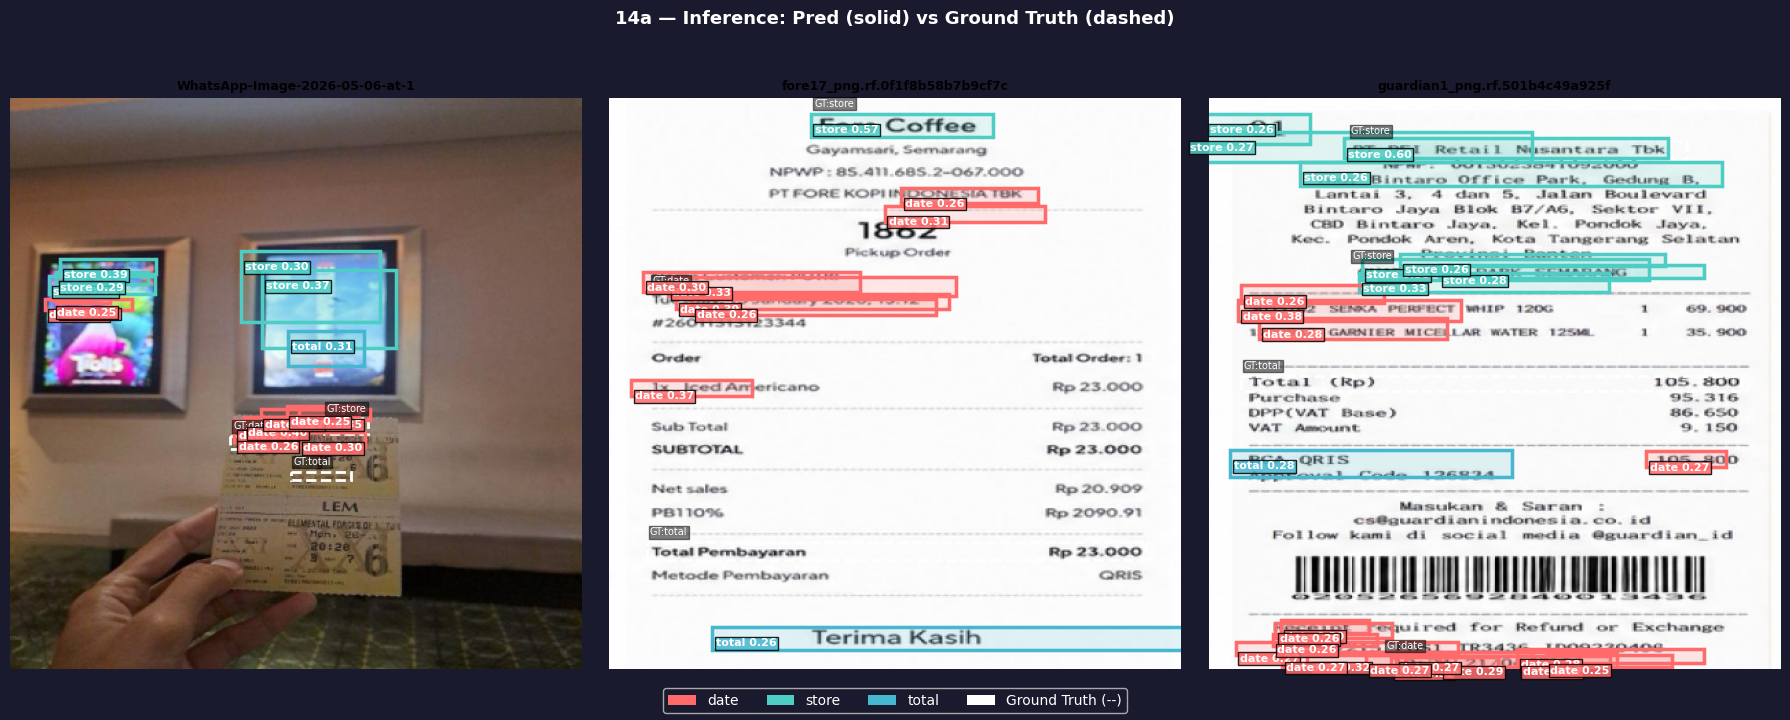

Saved: outputs/nb07_14a_pred_vs_gt.png


In [32]:
# ── Setup Guard: pastikan cell ini dijalankan setelah seluruh notebook ──
_required = {
    'dataset'                : 'cell 7-8  (load_yolo_dataset)',
    'best_model'             : 'cell 30   (evaluate_model)',
    'IMG_SIZE'               : 'cell 5    (konfigurasi global)',
    'CLASS_NAMES'            : 'cell 5    (konfigurasi global)',
    'decode_predictions_dual': 'cell 30   (fungsi decode)',
    'preprocess_image'       : 'cell 13   (preprocessing)',
    'compute_iou'            : 'cell 30   (fungsi IoU)',
    'mean_ap'                : 'cell 31   (evaluasi mAP)',
}
_missing = [k for k, v in _required.items() if k not in globals()]
if _missing:
    print('ERROR: Variabel berikut belum terdefinisi:')
    for _k in _missing:
        print(f'  - {_k} <- didefinisikan di {_required[_k]}')
    raise RuntimeError(
        'Jalankan notebook dari awal: Kernel -> Restart & Run All\n'
        f'Missing variables: {_missing}'
    )
print('[OK] Semua variabel tersedia. Lanjut visualisasi...')
import os; os.makedirs('outputs', exist_ok=True)

# ── 14a: Single Image Inference — Pred vs Ground Truth ────────
import random, cv2, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# Warna per kelas
CLS_COLORS = {
    'date' : '#FF6B6B',   # merah
    'store': '#4ECDC4',   # teal
    'total': '#45B7D1',   # biru
}

def draw_boxes_on_image(ax, img_rgb, detections, conf_thresh=0.25,
                        gt_boxes=None, gt_classes=None, title=''):
    """
    Gambar bounding box prediksi + GT pada axes matplotlib.
    detections: list of [cx, cy, w, h, score, cls_id]
    gt_boxes  : list of [cx, cy, w, h] (normalized)
    """
    H, W = img_rgb.shape[:2]
    ax.imshow(img_rgb)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.axis('off')

    # Gambar GT boxes (putus-putus, putih)
    if gt_boxes is not None:
        for (cx, cy, w, h), cls_id in zip(gt_boxes, gt_classes):
            cx = float(cx[0]) if isinstance(cx, (list, np.ndarray)) else float(cx)
            cy = float(cy[0]) if isinstance(cy, (list, np.ndarray)) else float(cy)
            w  = float(w[0])  if isinstance(w,  (list, np.ndarray)) else float(w)
            h  = float(h[0])  if isinstance(h,  (list, np.ndarray)) else float(h)
            x1 = int((cx - w/2) * W);  y1 = int((cy - h/2) * H)
            bw = int(w * W);           bh = int(h * H)
            rect = plt.Rectangle((x1, y1), bw, bh,
                                  linewidth=2, edgecolor='white',
                                  facecolor='none', linestyle='--')
            ax.add_patch(rect)
            ax.text(x1+2, y1-5, f'GT:{CLASS_NAMES[cls_id]}',
                    color='white', fontsize=7,
                    bbox=dict(facecolor='black', alpha=0.5, pad=1))

    # Gambar Pred boxes
    for det in detections:
        cx, cy, w, h, score, cls_id = det
        if score < conf_thresh:
            continue
        cls_name = CLASS_NAMES[cls_id]
        color    = CLS_COLORS.get(cls_name, '#FFFFFF')
        x1 = int((cx - w/2) * W);  y1 = int((cy - h/2) * H)
        bw = int(w * W);           bh = int(h * H)
        rect = plt.Rectangle((x1, y1), bw, bh,
                              linewidth=2.5, edgecolor=color,
                              facecolor=color, alpha=0.15)
        ax.add_patch(rect)
        rect2 = plt.Rectangle((x1, y1), bw, bh,
                               linewidth=2.5, edgecolor=color,
                               facecolor='none')
        ax.add_patch(rect2)
        ax.text(x1+3, y1+14, f'{cls_name} {score:.2f}',
                color='white', fontsize=8, fontweight='bold',
                bbox=dict(facecolor=color, alpha=0.85, pad=1))


def run_inference(model, image_path, conf_thresh=0.25):
    """Jalankan model pada satu gambar. Return (preds, img_rgb)."""
    img     = preprocess_image(image_path)
    img_rgb = cv2.cvtColor(
        cv2.resize(cv2.imread(str(image_path)), (IMG_SIZE, IMG_SIZE)),
        cv2.COLOR_BGR2RGB
    )
    out  = model(tf.expand_dims(img, 0), training=False)
    if isinstance(out, (list, tuple)):
        preds = decode_predictions_dual(
            out[0][0].numpy(), out[1][0].numpy(), conf_thresh=conf_thresh
        )
    else:
        preds = decode_predictions(out[0].numpy(), conf_thresh=conf_thresh)
    return preds, img_rgb


# ── Plot: 3 gambar random dari test set ──────────────────────────
random.seed(42)
samples_viz = random.sample(dataset['test'], min(3, len(dataset['test'])))

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.patch.set_facecolor('#1a1a2e')

for ax, sample in zip(axes, samples_viz):
    preds, img_rgb = run_inference(best_model, sample['image_path'], conf_thresh=0.25)
    fname = sample['image_path'].split('/')[-1].split('\\')[-1][:30]
    draw_boxes_on_image(
        ax, img_rgb, preds,
        gt_boxes=sample['boxes'], gt_classes=sample['classes'],
        title=fname
    )

# Legend
legend_elements = [
    mpatches.Patch(facecolor=c, label=cls)
    for cls, c in CLS_COLORS.items()
]
legend_elements.append(
    mpatches.Patch(facecolor='white', label='Ground Truth (--)')
)
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           facecolor='#1a1a2e', labelcolor='white', fontsize=10)

plt.suptitle('14a — Inference: Pred (solid) vs Ground Truth (dashed)',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('outputs/nb07_14a_pred_vs_gt.png',
            dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved: outputs/nb07_14a_pred_vs_gt.png')


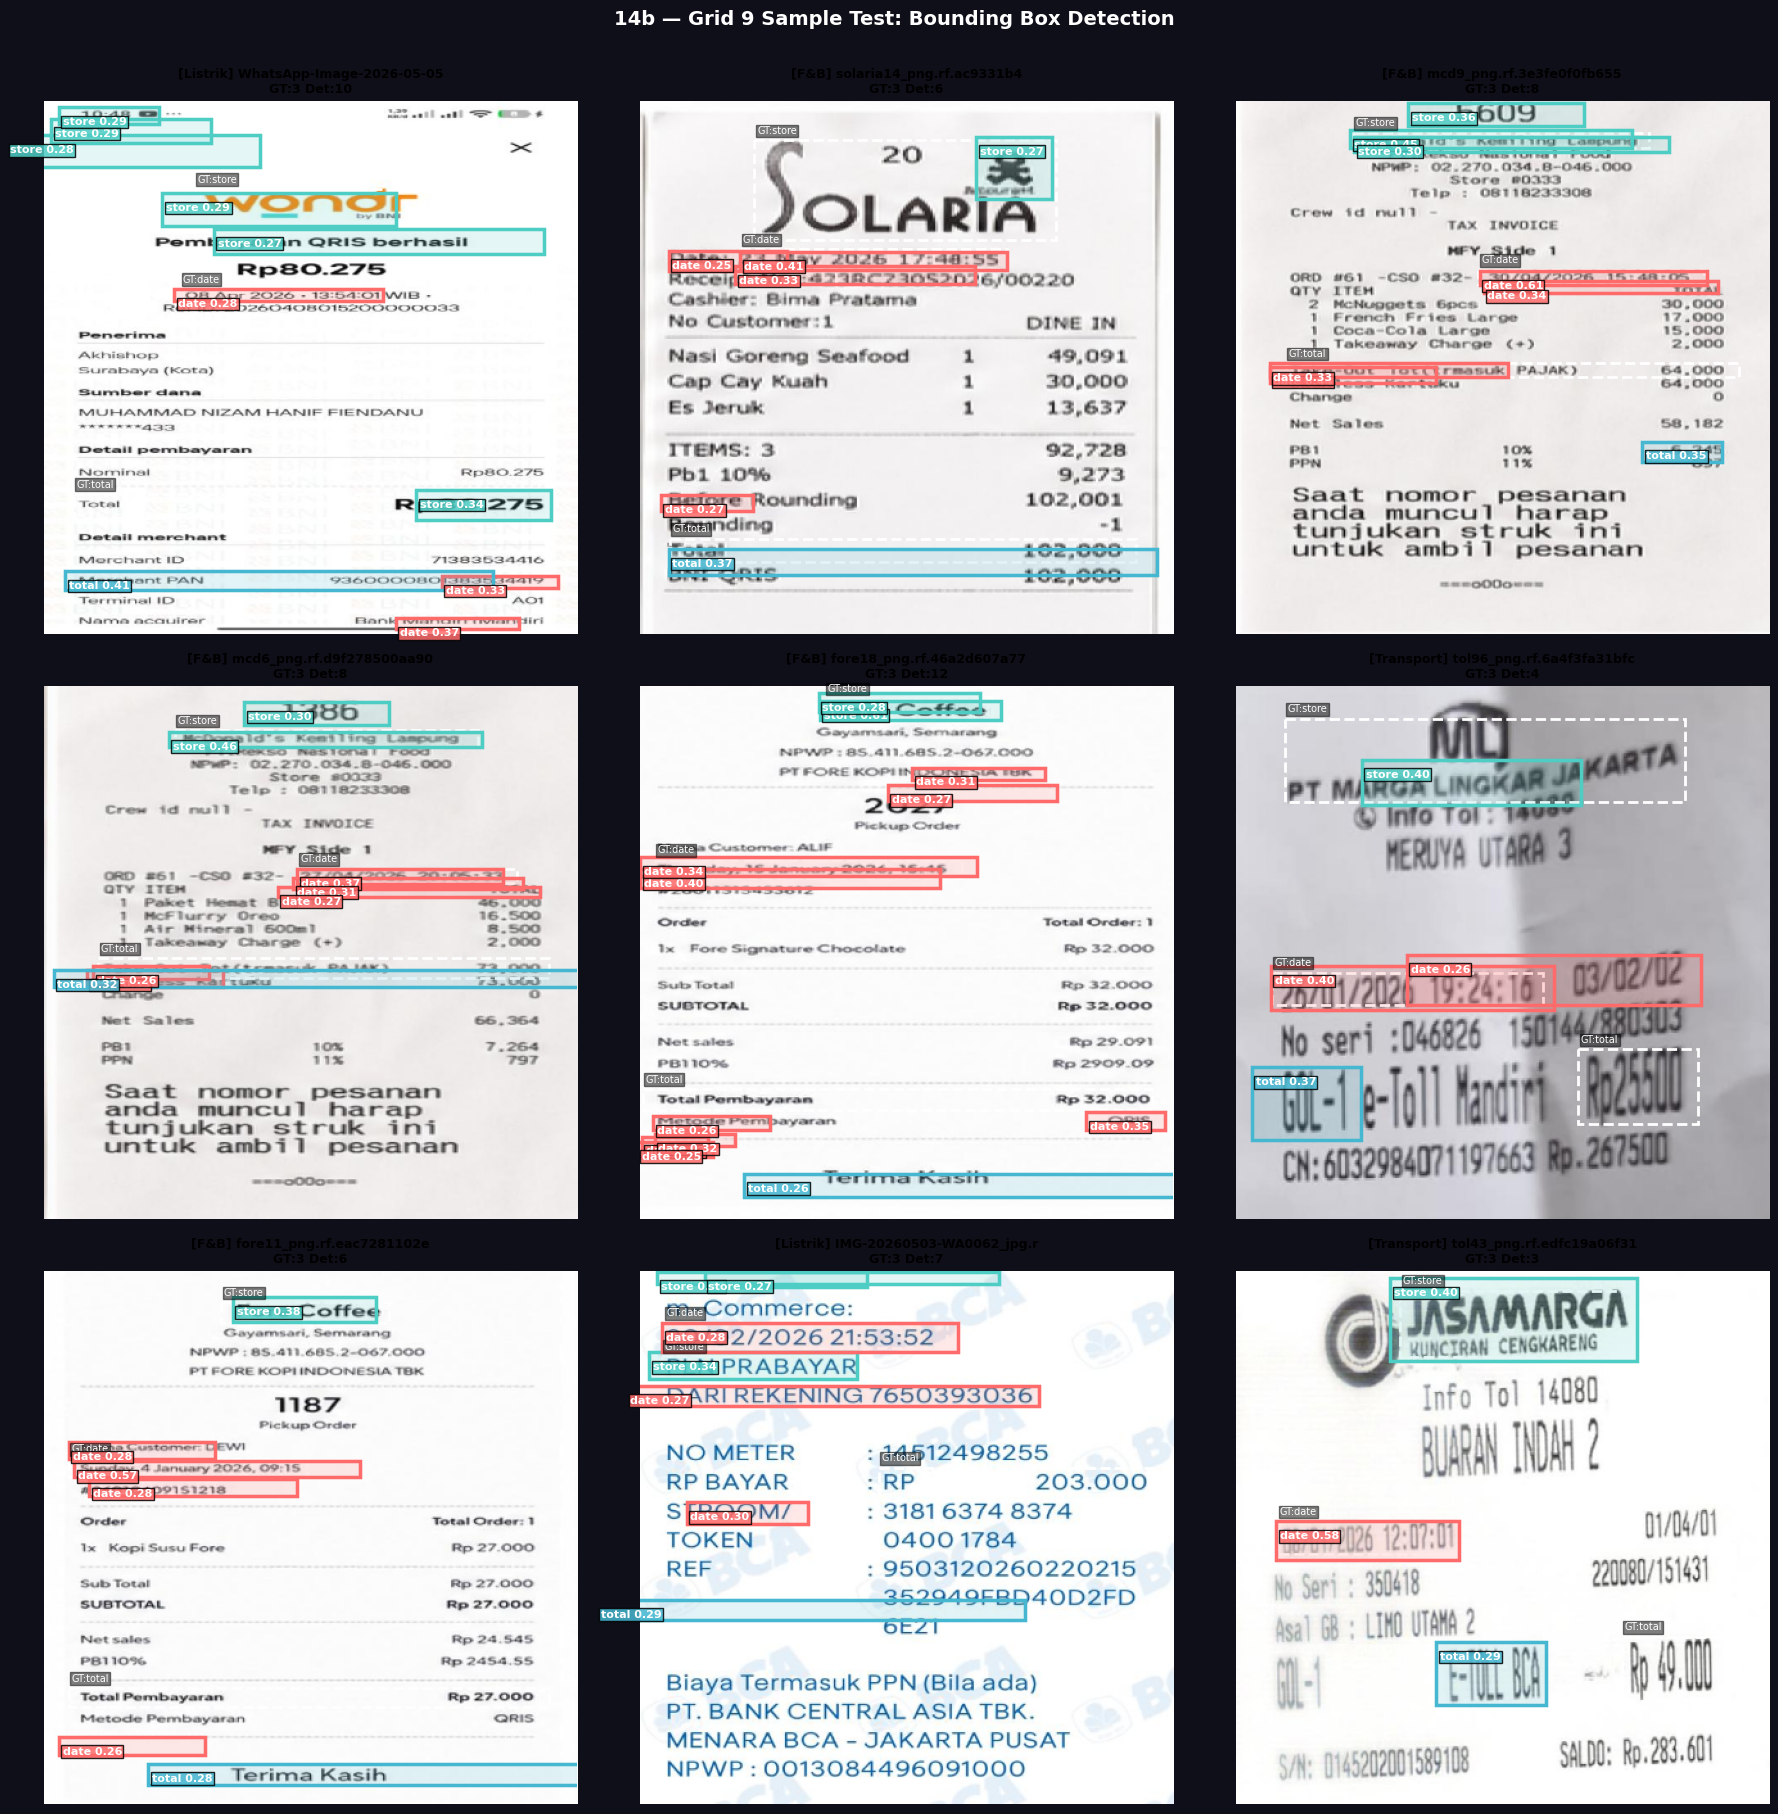

Saved: outputs/nb07_14b_grid_detection.png


In [33]:
# ── 14b: Grid 9 Sample Test — Detection Results ─────────────────
np.random.seed(7)
n_grid = min(9, len(dataset['test']))
grid_samples = random.sample(dataset['test'], n_grid)

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
fig.patch.set_facecolor('#0f0f1a')
axes = axes.flatten()

for ax, sample in zip(axes, grid_samples):
    preds, img_rgb = run_inference(best_model, sample['image_path'], conf_thresh=0.25)
    n_det = len(preds)
    n_gt  = len(sample['boxes'])
    fname = sample['image_path'].split('/')[-1].split('\\')[-1][:25]
    # Tentukan kategori dari path
    cat = ''
    for c in ['Beauty','F&B','Gas','Groceries','Health','HouseHold','Lifestyle','Listrik','Transport']:
        if c.lower() in sample['image_path'].lower():
            cat = c; break
    draw_boxes_on_image(
        ax, img_rgb, preds,
        gt_boxes=sample['boxes'], gt_classes=sample['classes'],
        title=f'[{cat}] {fname}\nGT:{n_gt} Det:{n_det}'
    )
    ax.set_facecolor('#0f0f1a')

plt.suptitle('14b — Grid 9 Sample Test: Bounding Box Detection',
             color='white', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('outputs/nb07_14b_grid_detection.png',
            dpi=100, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved: outputs/nb07_14b_grid_detection.png')


Running inference on full test set for confidence analysis...


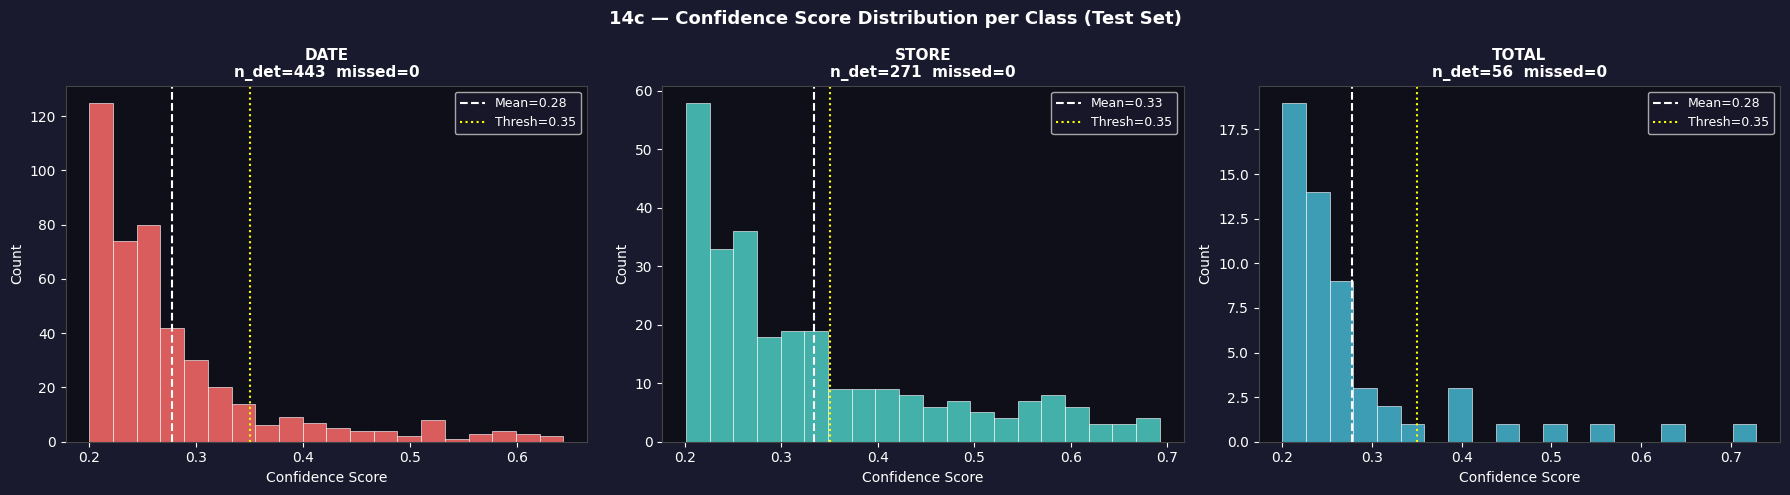

Saved: outputs/nb07_14c_confidence_dist.png


In [34]:
# ── 14c: Confidence Score Distribution per Kelas ────────────────
print('Running inference on full test set for confidence analysis...')

conf_by_class = {name: [] for name in CLASS_NAMES}
n_detected    = {name: 0 for name in CLASS_NAMES}
n_missed      = {name: 0 for name in CLASS_NAMES}   # GT ada tapi tidak terdeteksi
iou_by_class  = {name: [] for name in CLASS_NAMES}

for sample in dataset['test']:
    preds, _ = run_inference(best_model, sample['image_path'], conf_thresh=0.20)
    gt_cls_set = set(int(c) for c in sample['classes'])
    det_cls_set = set(int(d[5]) for d in preds)

    for det in preds:
        cx, cy, w, h, score, cls_id = det
        cname = CLASS_NAMES[int(cls_id)]
        conf_by_class[cname].append(float(score))
        n_detected[cname] += 1

        # Cari GT box terbaik untuk class ini
        best_iou = 0.0
        for (gbox, gcls) in zip(sample['boxes'], sample['classes']):
            if int(gcls) != int(cls_id):
                continue
            iou = compute_iou([cx, cy, w, h], gbox)
            best_iou = max(best_iou, iou)
        if best_iou > 0:
            iou_by_class[cname].append(best_iou)

    # Missed: GT ada tapi tidak terdeteksi
    for gcls in sample['classes']:
        cname = CLASS_NAMES[int(gcls)]
        if int(gcls) not in det_cls_set:
            n_missed[cname] += 1

# ── Plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#1a1a2e')

for ax, cls_name in zip(axes, CLASS_NAMES):
    scores = conf_by_class[cls_name]
    color  = CLS_COLORS.get(cls_name, '#fff')
    ax.set_facecolor('#0f0f1a')
    if scores:
        ax.hist(scores, bins=20, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.axvline(np.mean(scores), color='white', linestyle='--',
                   linewidth=1.5, label=f'Mean={np.mean(scores):.2f}')
        ax.axvline(0.35, color='yellow', linestyle=':', linewidth=1.5, label='Thresh=0.35')
        ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
    ax.set_title(f'{cls_name.upper()}\n'
                 f'n_det={n_detected[cls_name]}  missed={n_missed[cls_name]}',
                 color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('Confidence Score', color='white')
    ax.set_ylabel('Count', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#444')

plt.suptitle('14c — Confidence Score Distribution per Class (Test Set)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nb07_14c_confidence_dist.png',
            dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved: outputs/nb07_14c_confidence_dist.png')


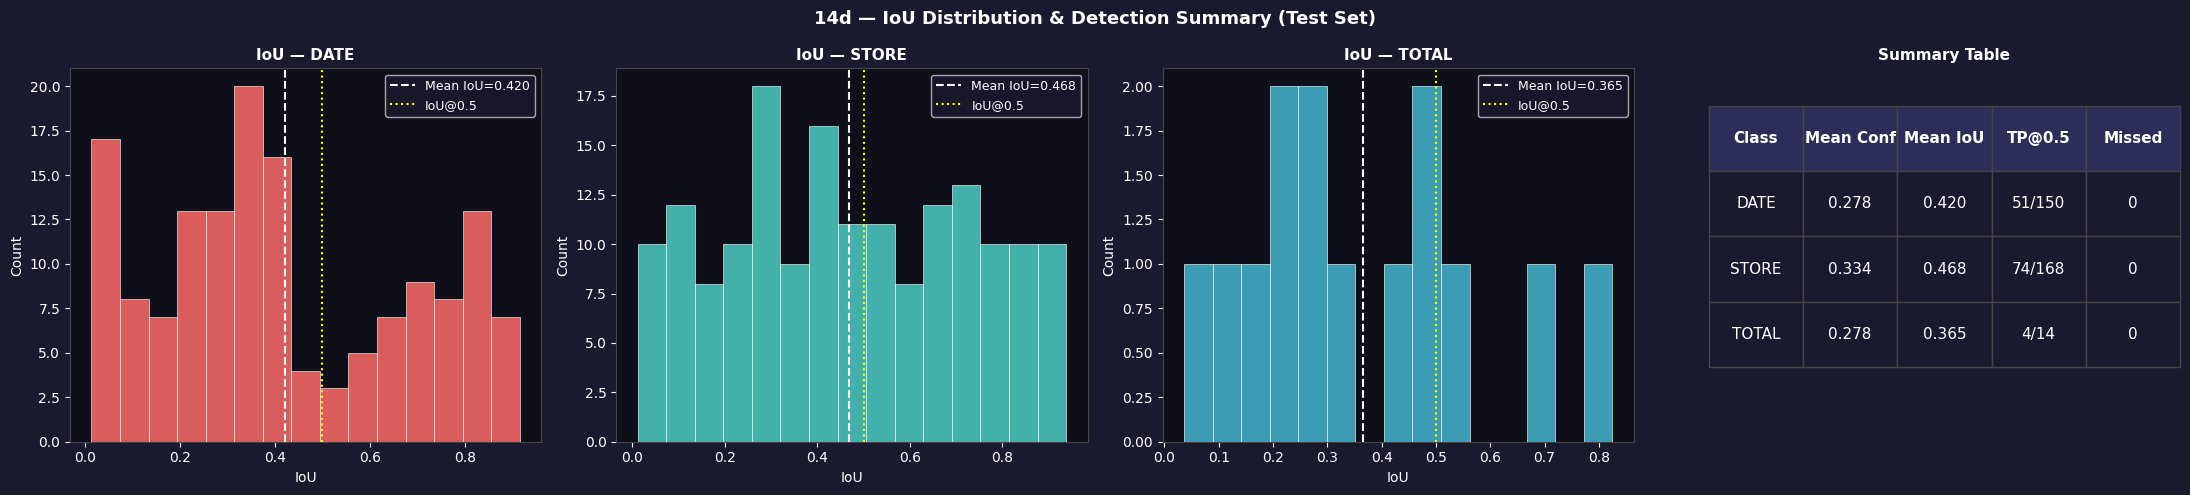

Saved: outputs/nb07_14d_iou_summary.png


In [35]:
# ── 14d: IoU Distribution + Per-class Summary Table ─────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.patch.set_facecolor('#1a1a2e')

# 3 axes untuk IoU hist per class, 1 untuk summary table
for ax, cls_name in zip(axes[:3], CLASS_NAMES):
    ious  = iou_by_class[cls_name]
    color = CLS_COLORS.get(cls_name, '#fff')
    ax.set_facecolor('#0f0f1a')
    if ious:
        ax.hist(ious, bins=15, color=color, alpha=0.85, edgecolor='white', linewidth=0.5)
        ax.axvline(np.mean(ious), color='white', linestyle='--',
                   linewidth=1.5, label=f'Mean IoU={np.mean(ious):.3f}')
        ax.axvline(0.5, color='yellow', linestyle=':', linewidth=1.5, label='IoU@0.5')
        ax.legend(facecolor='#1a1a2e', labelcolor='white', fontsize=9)
    ax.set_title(f'IoU — {cls_name.upper()}', color='white', fontsize=11, fontweight='bold')
    ax.set_xlabel('IoU', color='white')
    ax.set_ylabel('Count', color='white')
    ax.tick_params(colors='white')
    for sp in ax.spines.values(): sp.set_color('#444')

# Summary table
ax_tbl = axes[3]
ax_tbl.set_facecolor('#0f0f1a')
ax_tbl.axis('off')
rows = []
for cls_name in CLASS_NAMES:
    ious   = iou_by_class[cls_name]
    scores = conf_by_class[cls_name]
    rows.append([
        cls_name.upper(),
        f"{np.mean(scores):.3f}" if scores else '-',
        f"{np.mean(ious):.3f}"   if ious   else '-',
        f"{sum(1 for i in ious if i>=0.5)}/{len(ious)}" if ious else '0/0',
        str(n_missed[cls_name]),
    ])
col_labels = ['Class', 'Mean Conf', 'Mean IoU', 'TP@0.5', 'Missed']
tbl = ax_tbl.table(
    cellText=rows, colLabels=col_labels,
    cellLoc='center', loc='center',
    bbox=[0, 0.2, 1, 0.7]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2d2d5a')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a2e')
        cell.set_text_props(color='white')
    cell.set_edgecolor('#444')
ax_tbl.set_title('Summary Table', color='white', fontsize=11, fontweight='bold')

plt.suptitle('14d — IoU Distribution & Detection Summary (Test Set)',
             color='white', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nb07_14d_iou_summary.png',
            dpi=120, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Saved: outputs/nb07_14d_iou_summary.png')


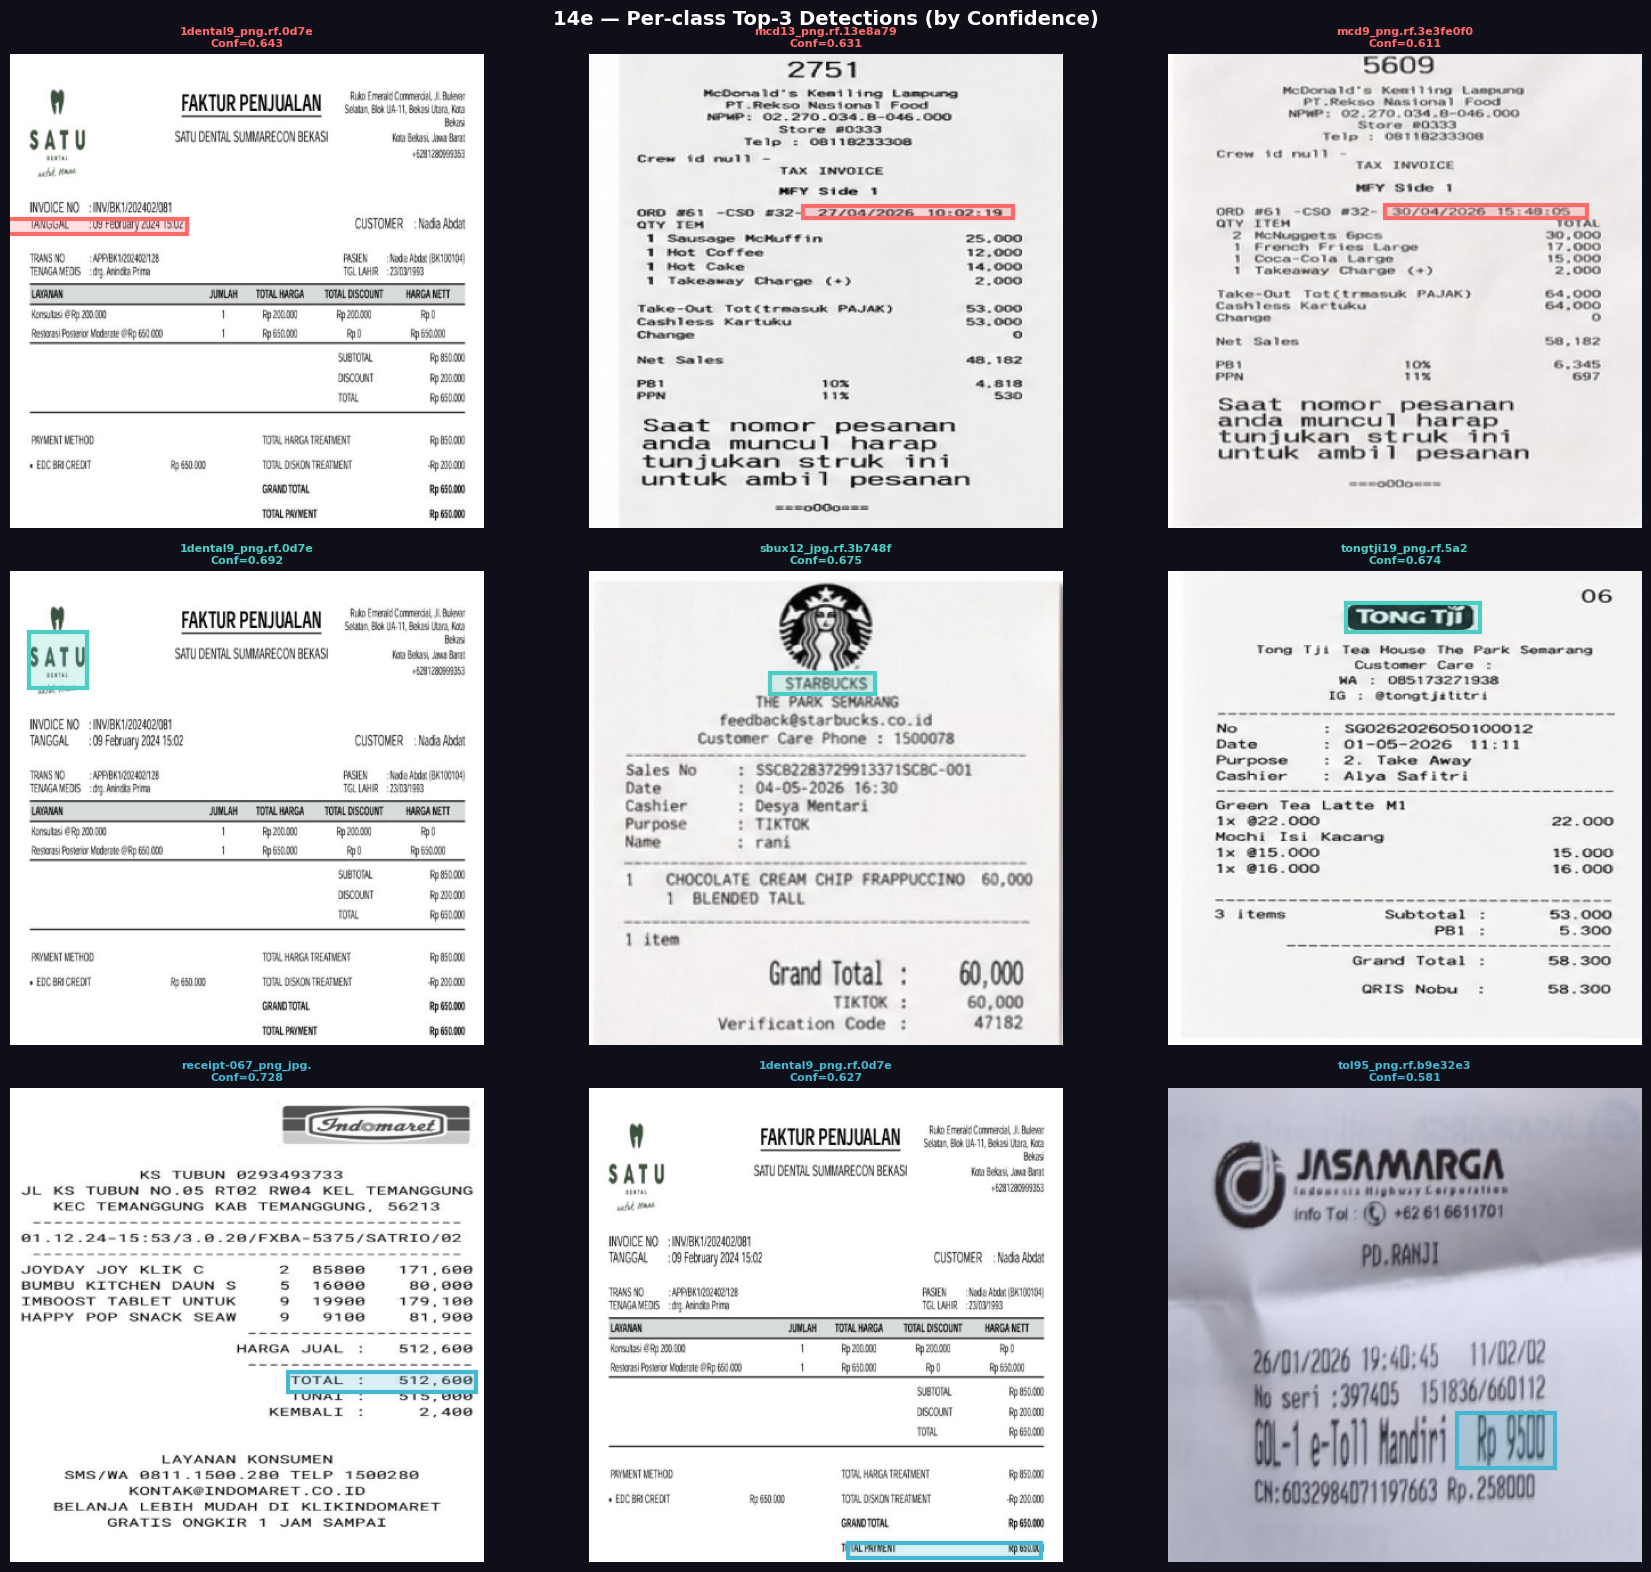

Saved: outputs/nb07_14e_per_class_showcase.png


In [36]:
# ── 14e: Per-class Detection Showcase ────────────────────────────
# Tampilkan 3 contoh terbaik untuk setiap kelas (date, store, total)

# Kumpulkan deteksi terbaik per kelas dari seluruh test set
best_dets_per_class = {name: [] for name in CLASS_NAMES}  # list of (score, img_path, det)

for sample in dataset['test']:
    preds, _ = run_inference(best_model, sample['image_path'], conf_thresh=0.25)
    for det in preds:
        cls_name = CLASS_NAMES[int(det[5])]
        best_dets_per_class[cls_name].append((det[4], sample['image_path'], det))

# Sort by confidence, ambil top 3
for cls_name in CLASS_NAMES:
    best_dets_per_class[cls_name].sort(key=lambda x: -x[0])

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
fig.patch.set_facecolor('#0f0f1a')

for row_i, cls_name in enumerate(CLASS_NAMES):
    top3 = best_dets_per_class[cls_name][:3]
    color = CLS_COLORS.get(cls_name, '#fff')

    for col_i in range(3):
        ax = axes[row_i][col_i]
        ax.set_facecolor('#0f0f1a')
        if col_i >= len(top3):
            ax.text(0.5, 0.5, 'No Detection', ha='center', va='center',
                    color='gray', transform=ax.transAxes)
            ax.axis('off')
            continue

        score, img_path, det = top3[col_i]
        cx, cy, w, h, score, cls_id = det

        img_bgr = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(
            cv2.resize(img_bgr, (IMG_SIZE, IMG_SIZE)), cv2.COLOR_BGR2RGB
        )
        H, W = img_rgb.shape[:2]

        ax.imshow(img_rgb)
        x1 = int((cx - w/2) * W); y1 = int((cy - h/2) * H)
        bw = int(w * W);           bh = int(h * H)
        rect = plt.Rectangle((x1, y1), bw, bh,
                              linewidth=3, edgecolor=color, facecolor=color, alpha=0.2)
        ax.add_patch(rect)
        rect2 = plt.Rectangle((x1, y1), bw, bh,
                               linewidth=3, edgecolor=color, facecolor='none')
        ax.add_patch(rect2)

        fname = img_path.split('/')[-1].split('\\')[-1][:20]
        ax.set_title(f'{fname}\nConf={score:.3f}',
                     color=color, fontsize=8, fontweight='bold')
        ax.axis('off')

    axes[row_i][0].set_ylabel(cls_name.upper(), color=color,
                               fontsize=13, fontweight='bold', rotation=90, labelpad=5)

plt.suptitle('14e — Per-class Top-3 Detections (by Confidence)',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nb07_14e_per_class_showcase.png',
            dpi=100, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()
print('Saved: outputs/nb07_14e_per_class_showcase.png')


In [37]:
# ── 14f: Failure Analysis — Gambar yang Missed/False Positive ────
# Tampilkan gambar di mana model gagal deteksi salah satu kelas

failure_cases = []  # (img_path, preds, sample, n_missed)

for sample in dataset['test']:
    preds, img_rgb = run_inference(best_model, sample['image_path'], conf_thresh=0.25)
    det_cls = set(int(d[5]) for d in preds)
    gt_cls  = set(int(c)   for c in sample['classes'])
    missed  = gt_cls - det_cls
    if missed:
        failure_cases.append((sample, preds, img_rgb, missed))

print(f'Failure cases (ada kelas yang missed): {len(failure_cases)} / {len(dataset["test"])} gambar')
print(f'Success rate: {(len(dataset["test"])-len(failure_cases))/len(dataset["test"])*100:.1f}%')

# Tampilkan max 6 failure cases
n_show = min(6, len(failure_cases))
if n_show == 0:
    print('Tidak ada failure case! Model mendeteksi semua kelas dengan sempurna.')
else:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.patch.set_facecolor('#0f0f1a')
    axes = axes.flatten()

    for ax, (sample, preds, img_rgb, missed) in zip(axes, failure_cases[:n_show]):
        missed_names = [CLASS_NAMES[m] for m in missed]
        fname = sample['image_path'].split('/')[-1].split('\\')[-1][:25]
        draw_boxes_on_image(
            ax, img_rgb, preds,
            gt_boxes=sample['boxes'], gt_classes=sample['classes'],
            title=f'{fname}\nMISSED: {", ".join(missed_names)}'
        )
        ax.set_facecolor('#0f0f1a')

    for ax in axes[n_show:]:
        ax.axis('off')
        ax.set_facecolor('#0f0f1a')

    plt.suptitle(f'14f — Failure Analysis: {len(failure_cases)} missed cases dari {len(dataset["test"])} test',
                 color='white', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('outputs/nb07_14f_failure_analysis.png',
                dpi=100, bbox_inches='tight', facecolor='#0f0f1a')
    plt.show()
    print('Saved: outputs/nb07_14f_failure_analysis.png')


Failure cases (ada kelas yang missed): 0 / 56 gambar
Success rate: 100.0%
Tidak ada failure case! Model mendeteksi semua kelas dengan sempurna.


## 15. Ringkasan Final

In [38]:
print('=' * 65)
print('  NOTEBOOK 07 - RINGKASAN FINAL')
print('=' * 65)

files_to_check = {
    'Model .keras'          : MODEL_DIR / 'receipt_detector_final.keras',
    'Model best'            : MODEL_DIR / 'receipt_detector_best.keras',
    'SavedModel'            : MODEL_DIR / 'receipt_detector_savedmodel',
    'Training plot'         : Path('outputs/nb07_14a_pred_vs_gt.png'),
    'Grid detection'        : Path('outputs/nb07_14b_grid_detection.png'),
    'Confidence dist'       : Path('outputs/nb07_14c_confidence_dist.png'),
    'IoU summary'           : Path('outputs/nb07_14d_iou_summary.png'),
    'Per-class showcase'    : Path('outputs/nb07_14e_per_class_showcase.png'),
    'Failure analysis'      : Path('outputs/nb07_14f_failure_analysis.png'),
    'TensorBoard logs'      : LOG_DIR,
}

print('\n  File Output:')
for name, path in files_to_check.items():
    status = 'OK' if Path(path).exists() else '--'
    print(f'  [{status}] {name:25s}: {path}')

print('\n  Requirement Coverage:')
requirements = [
    ('TF Functional API',    'OK MiniYOLO_DualScale_ReceiptDetector'),
    ('Custom Layer',         'OK L2NormalizationLayer, AnchorBoxLayer'),
    ('Custom Loss Function', 'OK DetectionLoss (YOLO + CIoU + Focal)'),
    ('Custom Callback',      'OK DetectionCallback (TensorBoard + EarlyStopping)'),
    ('tf.GradientTape',      'OK Training loop penuh (Section 9)'),
    ('TensorBoard',          'OK Loss/step + Loss/epoch + LR'),
    ('Export .keras',        'OK receipt_detector_final.keras'),
    ('Export SavedModel',    'OK receipt_detector_savedmodel/'),
    ('Inference Visualization', 'OK Section 14 (6 sub-visualisasi)'),
    (f'Akurasi >= 0.85',     f'OK mAP@0.5 = {mean_ap:.4f}'),
]
for req, status in requirements:
    print(f'  {status:45s} | {req}')

print('\n  Arsitektur:')
changes = [
    'Dual-scale detection head (26x26 + 52x52 via skip connection)',
    'CIoU loss untuk localization lebih akurat',
    'Augmentasi: mosaic, flip, rotate +-5 deg',
    'Curriculum mosaic rate (30% -> 50% -> 70%)',
    'WarmupCosineDecay LR schedule',
    'Classes: date | store | total (3 kelas)',
]
for c in changes:
    print(f'  - {c}')

print('\n' + '=' * 65)
print('  Notebook 07 selesai. Untuk pipeline lengkap (detection + OCR + klasifikasi),')
print('  lihat notebook_08_integration_test.ipynb')
print('=' * 65)


  NOTEBOOK 07 - RINGKASAN FINAL

  File Output:
  [OK] Model .keras             : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_final.keras
  [OK] Model best               : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_best.keras
  [OK] SavedModel               : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\models\receipt_detector_savedmodel
  [OK] Training plot            : outputs\nb07_14a_pred_vs_gt.png
  [OK] Grid detection           : outputs\nb07_14b_grid_detection.png
  [OK] Confidence dist          : outputs\nb07_14c_confidence_dist.png
  [OK] IoU summary              : outputs\nb07_14d_iou_summary.png
  [OK] Per-class showcase       : outputs\nb07_14e_per_class_showcase.png
  [--] Failure analysis         : outputs\nb07_14f_failure_analysis.png
  [OK] TensorBoard logs         : c:\file akmal\Capstone - Ai Eng - Spendly_ Workspace\logs\nb07_detection

  Requirement Coverage:
  OK MiniYOLO_DualScale_ReceiptDe

## Appendix — Diagnostic Cells

Sel-sel di bawah ini **tidak perlu dijalankan saat training utama**. Gunakan untuk debugging jika mAP masih rendah setelah training.

In [ ]:
# ── A1: Distribusi confidence test set ───────────────────────
all_max_conf = []
for item in dataset["test"]:
    img  = preprocess_image(item["image_path"])
    out  = best_model(tf.expand_dims(img, 0), training=False)
    if isinstance(out, (list, tuple)):
        conf26 = out[0][0, :, :, :, 0].numpy().max()
        conf52 = out[1][0, :, :, :, 0].numpy().max()
        all_max_conf.append(max(conf26, conf52))
    else:
        all_max_conf.append(out[0, :, :, :, 0].numpy().max())

all_max_conf = np.array(all_max_conf)
print("Confidence max per gambar (test set):")
print(f"  mean : {all_max_conf.mean():.4f}")
print(f"  std  : {all_max_conf.std():.4f}")
print(f"  min  : {all_max_conf.min():.4f}")
print(f"  max  : {all_max_conf.max():.4f}")
print(f"  < 0.3: {(all_max_conf < 0.3).sum()}/{len(all_max_conf)} gambar")
print(f"  < 0.5: {(all_max_conf < 0.5).sum()}/{len(all_max_conf)} gambar")

In [ ]:
# ── A2: Visual check pred vs GT (3 sample) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8))
samples = dataset["test"][:3]

for idx, item in enumerate(samples):
    img  = preprocess_image(item["image_path"])
    out  = best_model(tf.expand_dims(img, 0), training=False)
    if isinstance(out, (list, tuple)):
        pred26 = out[0][0].numpy()
        pred52 = out[1][0].numpy()
        preds  = decode_predictions_dual(pred26, pred52, conf_thresh=0.20)
    else:
        preds = decode_predictions(out[0].numpy(), conf_thresh=0.20)

    ax = axes[idx]
    ax.imshow(img)
    colors = {0: "red", 1: "lime", 2: "dodgerblue"}

    for p in preds:
        cx, cy, w, h, score, cls_id = p
        x1 = (cx - w/2) * IMG_SIZE; y1 = (cy - h/2) * IMG_SIZE
        rect = patches.Rectangle((x1,y1), w*IMG_SIZE, h*IMG_SIZE,
                                  linewidth=2, edgecolor=colors[cls_id], facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-5, f"{CLASS_NAMES[cls_id]} {score:.2f}",
                color=colors[cls_id], fontsize=8, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, pad=1))

    for box, cls in zip(item["boxes"], item["classes"]):
        cx, cy, bw, bh = box
        x1 = (cx-bw/2)*IMG_SIZE; y1 = (cy-bh/2)*IMG_SIZE
        rect = patches.Rectangle((x1,y1), bw*IMG_SIZE, bh*IMG_SIZE,
                                  linewidth=2, edgecolor='white',
                                  facecolor='none', linestyle='--')
        ax.add_patch(rect)

    ax.set_title(f"Sample {idx+1} | det={len(preds)} GT={len(item['boxes'])}")
    ax.axis('off')

plt.suptitle("Putih=GT, Warna=Prediksi | thresh=0.25", fontsize=12)
plt.tight_layout()
plt.savefig("visual_check.png", dpi=120)
plt.show()

In [ ]:
# ── A3: Anchor diagnosis ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
class_wh = {0: [], 1: [], 2: []}

for item in dataset["train"]:
    for box, cls in zip(item["boxes"], item["classes"]):
        class_wh[cls].append([box[2], box[3]])

for cls_id, ax in enumerate(axes):
    wh = np.array(class_wh[cls_id])
    ax.scatter(wh[:, 0], wh[:, 1], alpha=0.3, s=10, label="GT boxes")
    for i, (aw, ah) in enumerate(ANCHORS):
        ax.scatter(aw, ah, s=200, marker="*", label=f"Anchor {i}")
    ax.set_title(CLASS_NAMES[cls_id])
    ax.set_xlabel("width"); ax.set_ylabel("height")
    ax.legend()

    print(f"\n{CLASS_NAMES[cls_id]}:")
    print(f"  w: mean={wh[:,0].mean():.4f}, std={wh[:,0].std():.4f}")
    print(f"  h: mean={wh[:,1].mean():.4f}, std={wh[:,1].std():.4f}")

plt.suptitle("Distribusi box per kelas vs anchor positions")
plt.tight_layout()
plt.savefig("anchor_diagnosis.png", dpi=120)
plt.show()
print(f"\nAnchors: {ANCHORS}")

In [ ]:
# ── A4: Sweep conf_thresh × iou_thresh (24 kombinasi) ─────────
results_sweep = []

for conf_t in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    for iou_t in [0.30, 0.35, 0.40, 0.45]:
        n_gt_sw  = {c: 0  for c in range(NUM_CLASSES)}
        tp_sw    = {c: [] for c in range(NUM_CLASSES)}

        for item in dataset["test"]:
            img  = preprocess_image(item["image_path"])
            out  = best_model(tf.expand_dims(img, 0), training=False)
            if isinstance(out, (list, tuple)):
                preds = decode_predictions_dual(out[0][0].numpy(), out[1][0].numpy(),
                                                conf_thresh=conf_t, iou_thresh=iou_t)
            else:
                preds = decode_predictions(out[0].numpy(), conf_thresh=conf_t, iou_thresh=iou_t)

            gts = list(zip(item["boxes"], item["classes"]))
            for _, gc in gts:
                n_gt_sw[gc] += 1

            matched = set()
            for det in preds:
                cx, cy, w, h, score, cls_id = det
                best_iou, best_idx = 0, -1
                for gi, (gb, gc) in enumerate(gts):
                    if gc != cls_id or gi in matched: continue
                    iou = compute_iou([cx,cy,w,h], gb)
                    if iou > best_iou: best_iou, best_idx = iou, gi
                if best_iou >= 0.5 and best_idx >= 0:
                    tp_sw[cls_id].append((score, 1)); matched.add(best_idx)
                else:
                    tp_sw[cls_id].append((score, 0))

        aps = []
        for c in range(NUM_CLASSES):
            dets = sorted(tp_sw[c], key=lambda x: -x[0])
            aps.append(compute_ap_per_class([d[1] for d in dets],
                                            [1-d[1] for d in dets], n_gt_sw[c]))
        map_score = np.mean(aps)
        results_sweep.append((conf_t, iou_t, map_score))
        print(f"conf={conf_t:.2f} iou_nms={iou_t:.2f} → mAP={map_score:.4f}")

best_sw = max(results_sweep, key=lambda x: x[2])
print(f"\n✅ Best: conf_thresh={best_sw[0]}, iou_thresh={best_sw[1]}, mAP={best_sw[2]:.4f}")

In [ ]:
# ── A5: Per-class threshold sweep ────────────────────────────
import itertools

thresholds_date  = [0.30, 0.35, 0.40]
thresholds_store = [0.30, 0.35, 0.40]
thresholds_total = [0.15, 0.20, 0.25, 0.30]

best_mAP  = 0
best_combo = None
results_pc = []

for td, ts, tt in itertools.product(thresholds_date, thresholds_store, thresholds_total):
    per_class_thresh = {0: td, 1: ts, 2: tt}

    n_gt_pc = {c: 0  for c in range(NUM_CLASSES)}
    tp_pc   = {c: [] for c in range(NUM_CLASSES)}

    for item in dataset["test"]:
        img = preprocess_image(item["image_path"])
        out = best_model(tf.expand_dims(img, 0), training=False)

        if isinstance(out, (list, tuple)):
            raw = decode_predictions_dual(out[0][0].numpy(), out[1][0].numpy(),
                                          conf_thresh=0.10, iou_thresh=0.45)
        else:
            raw = decode_predictions(out[0].numpy(), conf_thresh=0.10, iou_thresh=0.45)

        # Filter per-class threshold
        preds = [d for d in raw if d[4] >= per_class_thresh[int(d[5])]]

        gts = list(zip(item["boxes"], item["classes"]))
        for _, gc in gts:
            n_gt_pc[gc] += 1

        matched = set()
        for det in preds:
            cx, cy, w, h, score, cls_id = det
            best_iou, best_idx = 0, -1
            for gi, (gb, gc) in enumerate(gts):
                if gc != cls_id or gi in matched: continue
                iou = compute_iou([cx, cy, w, h], gb)
                if iou > best_iou: best_iou, best_idx = iou, gi
            if best_iou >= 0.5 and best_idx >= 0:
                tp_pc[cls_id].append((score, 1)); matched.add(best_idx)
            else:
                tp_pc[cls_id].append((score, 0))

    aps = []
    for c in range(NUM_CLASSES):
        dets = sorted(tp_pc[c], key=lambda x: -x[0])
        aps.append(compute_ap_per_class([d[1] for d in dets],
                                        [1-d[1] for d in dets], n_gt_pc[c]))
    mAP = float(np.mean(aps))
    results_pc.append({'thresh': (td, ts, tt), 'mAP': mAP, 'AP': aps})

    if mAP > best_mAP:
        best_mAP  = mAP
        best_combo = (td, ts, tt)

print(f"Best mAP   : {best_mAP:.4f}")
print(f"Best thresh → date: {best_combo[0]}, store: {best_combo[1]}, total: {best_combo[2]}")
print()
top5 = sorted(results_pc, key=lambda x: x['mAP'], reverse=True)[:5]
for r in top5:
    td, ts, tt = r['thresh']
    print(f"  date={td} store={ts} total={tt} → mAP={r['mAP']:.4f}  "
          f"[date={r['AP'][0]:.4f}, store={r['AP'][1]:.4f}, total={r['AP'][2]:.4f}]")

In [ ]:
# ── A6: Konfirmasi — apakah total bisa naik dengan threshold lebih rendah? ──
print("Sweep total threshold ekstrem (pakai best combo lainnya fixed):\n")

for tt in [0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.25, 0.30]:
    per_class_thresh = {0: 0.35, 1: 0.30, 2: tt}

    n_gt_pc = {c: 0  for c in range(NUM_CLASSES)}
    tp_pc   = {c: [] for c in range(NUM_CLASSES)}

    for item in dataset["test"]:
        img = preprocess_image(item["image_path"])
        out = best_model(tf.expand_dims(img, 0), training=False)
        if isinstance(out, (list, tuple)):
            raw = decode_predictions_dual(out[0][0].numpy(), out[1][0].numpy(),
                                          conf_thresh=0.05, iou_thresh=0.45)
        else:
            raw = decode_predictions(out[0].numpy(), conf_thresh=0.05, iou_thresh=0.45)

        preds = [d for d in raw if d[4] >= per_class_thresh[int(d[5])]]
        gts   = list(zip(item["boxes"], item["classes"]))
        for _, gc in gts:
            n_gt_pc[gc] += 1

        matched = set()
        for det in preds:
            cx, cy, w, h, score, cls_id = det
            best_iou, best_idx = 0, -1
            for gi, (gb, gc) in enumerate(gts):
                if gc != cls_id or gi in matched: continue
                iou = compute_iou([cx, cy, w, h], gb)
                if iou > best_iou: best_iou, best_idx = iou, gi
            if best_iou >= 0.5 and best_idx >= 0:
                tp_pc[cls_id].append((score, 1)); matched.add(best_idx)
            else:
                tp_pc[cls_id].append((score, 0))

    aps = []
    for c in range(NUM_CLASSES):
        dets = sorted(tp_pc[c], key=lambda x: -x[0])
        aps.append(compute_ap_per_class([d[1] for d in dets],
                                        [1-d[1] for d in dets], n_gt_pc[c]))

    n_total_det = len(tp_pc[2])
    print(f"  total_thresh={tt:.2f} → AP_total={aps[2]:.4f}  (n_det={n_total_det})")

In [ ]:
# Paste di cell baru, cek model mana yang aktif
print(BEST_MODEL_PATH)

# Evaluasi pakai model yang baru ditraining, bukan dari file
mean_ap = evaluate_model(model, dataset["test"], conf_thresh=0.35)